# PoC-2 — conservative CWT disagreement-gated fusion

**Objective.** Test whether a genuinely complementary continuous-wavelet
time-frequency expert can selectively correct errors from the dominant
temporal expert. The proposed fusion defaults to the anchor expert and
overrides it only when a learned disagreement gate has sufficiently strong
evidence that the alternative expert is correct.

This notebook is an executed scientific PoC. It is designed to answer the
question `does fusion add predictive value beyond the strongest individual
expert?`, not merely whether it improves over a fixed probability mean.

## Hypotheses

- **H1 — Complementarity:** a CWT expert captures PD structure not captured by
  the raw temporal expert.
- **H2 — Recoverability:** a meaningful subset of temporal-expert errors can
  be corrected by the CWT expert.
- **H3 — Detectability:** confidence and compact signal/meta-features identify
  cases where CWT should override the temporal expert.
- **H4 — Conservative fusion:** a learned gate that defaults to the best
  expert and overrides only with strong evidence can beat both entropy
  averaging and the best individual expert.

## Protocol and scope

PoC-1 already inspected `Te0`; therefore PoC-2 treats `Tr0 + Va0 + Te0` as
one development pool and reserves `Te1` as the new untouched final test.
`Te1` is not loaded until the explicitly marked locked-evaluation cell and
is not used for architecture, hyperparameter, calibration, threshold, gate,
or feature decisions. `Te2` is not loaded or displayed and remains reserved
for a later out-of-distribution/generalization phase.

The MATLAB files expose signal arrays and labels, but no source-stator,
source-pulse, measurement, acquisition, antenna, augmentation, or repeated-
observation identifier. Consequently this notebook uses stratified 5-fold
cross-fitting and records that group-aware splitting was not possible from the
supplied schema. The limitation is not silently treated as absence of
dependence.

All learned preprocessing statistics are fit inside the relevant development
fold. Expert OOF predictions are generated by models that did not train on the
corresponding held-out rows. Gate fitting uses only OOF predictions and is
separated from calibration and override-threshold selection.

In [1]:
import gc
import hashlib
import json
import math
import os
import platform
import random
import struct
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.io import loadmat
from scipy.stats import binomtest, kurtosis, skew
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / 'poc' / 'experiments' / 'poc.ipynb').is_file() and (PROJECT_ROOT / 'data' / 'datasets.yaml').is_file():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
if not ((PROJECT_ROOT / 'poc' / 'experiments' / 'poc.ipynb').is_file() and (PROJECT_ROOT / 'data' / 'datasets.yaml').is_file()):
    raise RuntimeError('Run this notebook from the repository or set its working directory to the repository root.')

CATALOG_ROOT_VALUE = os.environ.get('PD_DATASETS_CATALOG_ROOT')
if not CATALOG_ROOT_VALUE:
    raise RuntimeError('Set PD_DATASETS_CATALOG_ROOT to the external datasets_catalog before running PoC-2.')
CATALOG_ROOT = Path(CATALOG_ROOT_VALUE).expanduser().resolve()
DATASET_ID = 'engineering-partial-discharge-noise-signals'
DATASET_VERSION = 'v1'
DATASET_ROOT = CATALOG_ROOT / 'data' / 'raw' / 'dataset-pd-noise'
if not DATASET_ROOT.is_dir():
    raise RuntimeError(f'Catalog dataset path does not exist: {DATASET_ROOT}')

RESULT_DIR = PROJECT_ROOT / 'poc' / 'results'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
SEED = int(os.environ.get('POC2_SEED', '20260901'))
N_SPLITS = 5
CV_MAX_EPOCHS = int(os.environ.get('POC2_CV_MAX_EPOCHS', '8'))
PATIENCE = int(os.environ.get('POC2_PATIENCE', '2'))
BATCH_SIZE = int(os.environ.get('POC2_BATCH_SIZE', '256'))
INFERENCE_BATCH_SIZE = int(os.environ.get('POC2_INFERENCE_BATCH_SIZE', '2048'))
TORCH_THREADS = int(os.environ.get('POC2_TORCH_THREADS', str(min(8, os.cpu_count() or 1))))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(TORCH_THREADS)
torch.use_deterministic_algorithms(False)

def git_commit():
    try:
        return subprocess.check_output(['git', '-C', str(PROJECT_ROOT), 'rev-parse', 'HEAD'], text=True).strip()
    except Exception:
        return 'unavailable'

def safe_version(module):
    return getattr(module, '__version__', 'unknown')

print('Python:', sys.version.replace('\n', ' '))
print('Python executable:', sys.executable)
print('Environment:', os.environ.get('CONDA_DEFAULT_ENV', 'not reported'))
print('PyTorch:', torch.__version__)
print('NumPy:', safe_version(np), '| pandas:', safe_version(pd))
import sklearn
import scipy
print('scikit-learn:', safe_version(sklearn), '| SciPy:', safe_version(scipy))
print('CUDA available:', torch.cuda.is_available(), '| device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Seed:', SEED, '| torch threads:', torch.get_num_threads())
print('Working directory:', Path.cwd().resolve())
print('Dataset catalog root:', CATALOG_ROOT)
print('Dataset:', DATASET_ID, DATASET_VERSION)
print('Repository commit:', git_commit())
print('Note: this run uses the mamba environment named partial-discharge; CUDA is used when available.')
if os.environ.get('CONDA_DEFAULT_ENV') not in (None, 'partial-discharge'):
    print('WARNING: CONDA_DEFAULT_ENV is not partial-discharge; verify the kernel before treating results as final.')

Python: 3.11.16 | packaged by conda-forge | (main, Aug 21 2026, 22:44:51) [GCC 14.4.0]
Python executable: /home/polivares/.local/share/mamba/envs/partial-discharge/bin/python
Environment: partial-discharge
PyTorch: 2.9.1
NumPy: 2.4.6 | pandas: 3.0.5
scikit-learn: 1.9.0 | SciPy: 1.17.1
CUDA available: True | device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Seed: 20260901 | torch threads: 8
Working directory: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/experiments
Dataset catalog root: /home/polivares/Dropbox/Work/Research/datasets_catalog
Dataset: engineering-partial-discharge-noise-signals v1
Repository commit: acfe24dd316150c3228a23e30fceafc637d1dcbb
Note: this run uses the mamba environment named partial-discharge; CUDA is used when available.


## 1. Repository and dataset inspection

The loader below consumes only the external catalog path supplied through
`PD_DATASETS_CATALOG_ROOT`. Raw data are not copied into the repository. The
expected MATLAB schema is checked before modeling, including the 400-sample
signal length and the balanced class counts recorded in the catalog.

In [2]:
EXPECTED_COUNTS = {
    'Tr0.mat': {0: 6130, 1: 6130},
    'Va0.mat': {0: 1533, 1: 1533},
    'Te0.mat': {0: 22985, 1: 22985},
    'Te1.mat': {0: 234646, 1: 234646},
}
DEV_FILES = ('Tr0.mat', 'Va0.mat', 'Te0.mat')
FINAL_FILE = 'Te1.mat'
FORBIDDEN_FILE = 'Te2.mat'

def _decode_matlab_categorical(workspace, n_samples):
    raw = np.asarray(workspace, dtype=np.uint8).reshape(-1).tobytes()
    pd_marker = bytes([16, 0, 2, 0]) + b'PD'
    if b'NonPD' not in raw or pd_marker not in raw:
        raise ValueError('The NonPD/PD categories were not found in the MATLAB payload.')
    marker = struct.pack('<II', 2, n_samples)
    candidates = []
    offset = 0
    while True:
        position = raw.find(marker, offset)
        if position < 0:
            break
        code_start = position + len(marker)
        codes = np.frombuffer(raw, dtype=np.uint8, count=n_samples, offset=code_start).copy()
        if codes.size == n_samples and np.all(np.isin(codes, [1, 2])):
            candidates.append(codes)
        offset = position + 1
    if len(candidates) != 1:
        raise ValueError(f'Could not uniquely identify categorical codes: {len(candidates)} candidates.')
    return (candidates[0] == 2).astype(np.int64)

def load_partition(file_id):
    if file_id not in (*DEV_FILES, FINAL_FILE):
        raise ValueError(f'Partition outside the PoC-2 scope: {file_id}')
    path = DATASET_ROOT / file_id
    if not path.is_file():
        raise FileNotFoundError(path)
    table = Path(file_id).stem
    mat = loadmat(path, squeeze_me=False, struct_as_record=False, variable_names=[table, '__function_workspace__'])
    record = mat[table][0, 0]
    signal_cells = np.asarray(record.signals, dtype=object).reshape(-1)
    signals = np.stack([np.asarray(item, dtype=np.float32).reshape(-1) for item in signal_cells])
    if signals.ndim != 2 or signals.shape[1] != 400:
        raise ValueError(f'{file_id}: unexpected signal shape: {signals.shape}')
    labels = _decode_matlab_categorical(mat['__function_workspace__'], signals.shape[0])
    counts = dict(sorted(Counter(labels.tolist()).items()))
    if counts != EXPECTED_COUNTS[file_id]:
        raise ValueError(f'{file_id}: counts {counts}; expected {EXPECTED_COUNTS[file_id]}')
    if not np.isfinite(signals).all():
        raise ValueError(f'{file_id}: signals contain non-finite values.')
    return signals, labels

def fit_standardizer(values):
    values = np.asarray(values, dtype=np.float32)
    mean = values.mean(axis=0, keepdims=True).astype(np.float32)
    std = values.std(axis=0, keepdims=True).astype(np.float32)
    std[std < 1e-6] = 1.0
    return mean, std

def apply_standardizer(values, mean, std):
    return ((np.asarray(values, dtype=np.float32) - mean) / std).astype(np.float32)

def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(np.asarray(values, dtype=np.float64), -40, 40)))

def normalized_entropy(probability):
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1.0 - 1e-7)
    return -(probability * np.log2(probability) + (1.0 - probability) * np.log2(1.0 - probability))

def expected_calibration_error(labels, probabilities, bins=10):
    labels = np.asarray(labels).astype(int)
    probabilities = np.asarray(probabilities, dtype=float)
    edges = np.linspace(0.0, 1.0, bins + 1)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        mask = (probabilities >= lower) & (probabilities < upper if upper < 1 else probabilities <= upper)
        if mask.any():
            error += mask.mean() * abs(probabilities[mask].mean() - labels[mask].mean())
    return float(error)

def select_threshold(labels, probabilities):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = np.array([matthews_corrcoef(labels, np.asarray(probabilities) >= threshold) for threshold in thresholds])
    best_score = scores.max()
    candidates = thresholds[np.isclose(scores, best_score)]
    return float(candidates[np.argmin(np.abs(candidates - 0.5))])

def evaluate(labels, probabilities, threshold):
    labels = np.asarray(labels).astype(int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = probabilities >= threshold
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'threshold': float(threshold),
        'mcc': float(matthews_corrcoef(labels, predictions)),
        'accuracy': float(accuracy_score(labels, predictions)),
        'precision': float(precision_score(labels, predictions, zero_division=0)),
        'recall_tpr': float(recall_score(labels, predictions, zero_division=0)),
        'specificity': float(tn / (tn + fp)) if (tn + fp) else 0.0,
        'f1': float(f1_score(labels, predictions, zero_division=0)),
        'fpr': float(fp / (fp + tn)) if (fp + tn) else 0.0,
        'roc_auc': float(roc_auc_score(labels, probabilities)),
        'pr_auc': float(average_precision_score(labels, probabilities)),
        'brier': float(brier_score_loss(labels, probabilities)),
        'ece_10_bins': expected_calibration_error(labels, probabilities),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def prediction_metrics(labels, predictions):
    labels = np.asarray(labels).astype(int)
    predictions = np.asarray(predictions).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'mcc': float(matthews_corrcoef(labels, predictions)),
        'accuracy': float(accuracy_score(labels, predictions)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

,partition,n_samples,n_features,NonPD,PD,bytes
0,Tr0.mat,12260,400,6130,6130,18465121
1,Va0.mat,3066,400,1533,1533,4618033
2,Te0.mat,45970,400,22985,22985,69235113


Development pool shape: (61296, 400) | labels: {0: 30648, 1: 30648}
Development files: ('Tr0.mat', 'Va0.mat', 'Te0.mat')
Group metadata available: False
Limitation: MAT schema contains no physical-observation grouping key; using StratifiedKFold.


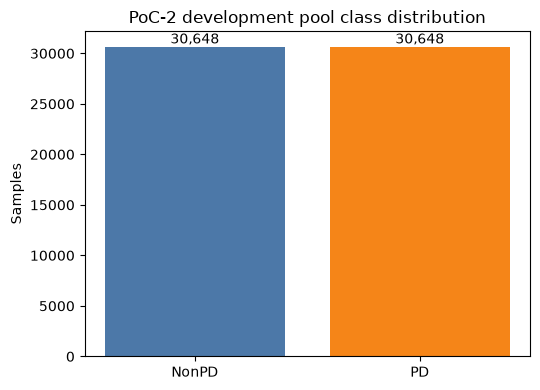

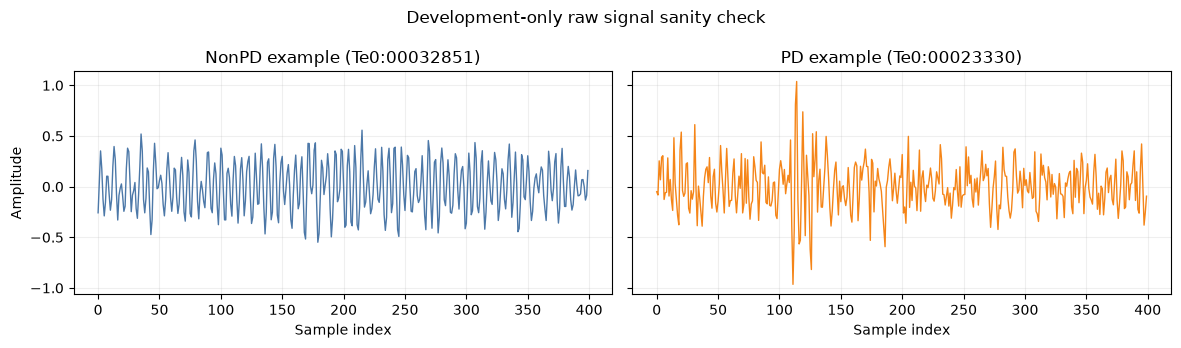

In [3]:
partitions = {file_id: load_partition(file_id) for file_id in DEV_FILES}
loaded_partitions = tuple(partitions)
assert set(loaded_partitions).isdisjoint({FINAL_FILE, FORBIDDEN_FILE})
audit = pd.DataFrame([
    {
        'partition': file_id,
        'n_samples': int(x.shape[0]),
        'n_features': int(x.shape[1]),
        'NonPD': int((y == 0).sum()),
        'PD': int((y == 1).sum()),
        'bytes': int((DATASET_ROOT / file_id).stat().st_size),
    }
    for file_id, (x, y) in partitions.items()
])
display(audit)
X_dev = np.concatenate([partitions[file_id][0] for file_id in DEV_FILES], axis=0)
y_dev = np.concatenate([partitions[file_id][1] for file_id in DEV_FILES], axis=0)
partition_dev = np.concatenate([
    np.repeat(Path(file_id).stem, len(partitions[file_id][1])) for file_id in DEV_FILES
])
sample_id_dev = np.array([
    f'{partition}:{row:08d}'
    for partition, count in ((Path(file_id).stem, len(partitions[file_id][1])) for file_id in DEV_FILES)
    for row in range(count)
], dtype=object)
print('Development pool shape:', X_dev.shape, '| labels:', dict(sorted(Counter(y_dev.tolist()).items())))
print('Development files:', loaded_partitions)
print('Group metadata available:', False)
print('Limitation: MAT schema contains no physical-observation grouping key; using StratifiedKFold.')

fig, ax = plt.subplots(figsize=(5.5, 4))
counts = pd.Series(y_dev).map({0: 'NonPD', 1: 'PD'}).value_counts().reindex(['NonPD', 'PD'])
ax.bar(counts.index, counts.values, color=['#4c78a8', '#f58518'])
ax.set_title('PoC-2 development pool class distribution')
ax.set_ylabel('Samples')
for index, value in enumerate(counts.values):
    ax.text(index, value, f'{value:,}', ha='center', va='bottom')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_class_distribution.png', dpi=140)
display(fig)
plt.close(fig)

rng = np.random.default_rng(SEED)
raw_example_indices = [int(rng.choice(np.flatnonzero(y_dev == label))) for label in [0, 1]]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, index, label_name, color in zip(axes, raw_example_indices, ['NonPD', 'PD'], ['#4c78a8', '#f58518']):
    ax.plot(X_dev[index], color=color, linewidth=1.0)
    ax.set_title(f'{label_name} example ({sample_id_dev[index]})')
    ax.set_xlabel('Sample index')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Amplitude')
fig.suptitle('Development-only raw signal sanity check')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_raw_examples.png', dpi=140)
display(fig)
plt.close(fig)

## 2. CWT representation and visual sanity check

The installed environment does not provide a reliable Morse-wavelet
implementation, so this PoC uses a fixed complex Morlet fallback. The CWT is
computed in the FFT domain, converted to log-power, clipped at a fixed floor,
and downsampled only along time to keep the representation small. The
per-pixel mean and standard deviation are learned separately from each fold's
inner training data; they are not estimated from held-out OOF rows.

Sampling frequency is not recorded in the retained catalog metadata. The CWT
axes therefore use sample index and dimensionless wavelet scales, not physical
Hertz. This is an explicit limitation rather than an invented frequency axis.

Reusing validated development-only CWT cache: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc2_cwt_log_float16.dat
CWT wavelet: complex Morlet fallback (Morse unavailable in environment)
Scales: 32 | voices per octave: not applicable for fixed Morlet scales
Sampling frequency: not recorded in catalog; axes use sample index/scales
Scalogram dimensions: (32, 120) | log-power floor: -10.0


/tmp/ipykernel_628152/3353279647.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


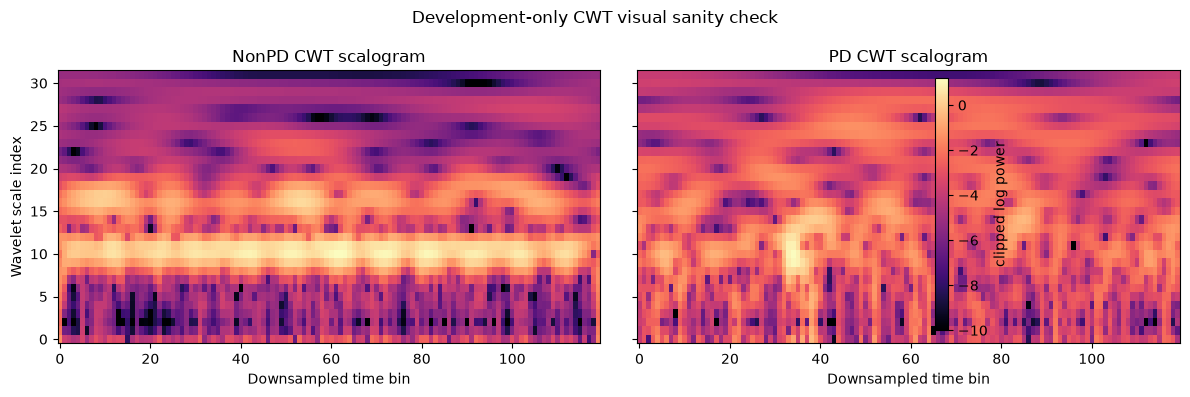

In [4]:
CWT_WAVELET = 'complex Morlet fallback (Morse unavailable in environment)'
CWT_MORLET_W0 = 6.0
CWT_SCALES = np.geomspace(1.5, 64.0, 32).astype(np.float32)
CWT_TIME_BINS = 120
CWT_CLIP_FLOOR = -10.0
CWT_EPS = 1e-8
CWT_TIME_INDEX = np.linspace(0, X_dev.shape[1] - 1, CWT_TIME_BINS).round().astype(int)
CWT_SHAPE = (len(CWT_SCALES), CWT_TIME_BINS)

def cwt_log_batch(values):
    values = np.asarray(values, dtype=np.float32)
    if values.ndim != 2 or values.shape[1] != X_dev.shape[1]:
        raise ValueError(f'Expected batch shape (n, {X_dev.shape[1]}), got {values.shape}')
    n_samples, n_time = values.shape
    signal_fft = np.fft.fft(values, axis=1)
    centered_time = np.arange(n_time, dtype=np.float64) - (n_time // 2)
    output = np.empty((n_samples, len(CWT_SCALES), CWT_TIME_BINS), dtype=np.float32)
    for scale_index, scale in enumerate(CWT_SCALES.astype(np.float64)):
        wavelet = np.exp(-0.5 * (centered_time / scale) ** 2) * np.exp(1j * CWT_MORLET_W0 * centered_time / scale) / np.sqrt(scale)
        wavelet_fft = np.fft.fft(np.fft.ifftshift(wavelet))
        coefficients = np.fft.ifft(signal_fft * np.conj(wavelet_fft)[None, :], axis=1)
        power = np.abs(coefficients) ** 2
        output[:, scale_index, :] = np.maximum(
            np.log(power[:, CWT_TIME_INDEX] + CWT_EPS), CWT_CLIP_FLOOR
        ).astype(np.float32)
    return output

CWT_CACHE_PATH = RESULT_DIR / 'poc2_cwt_log_float16.dat'
CWT_META_PATH = RESULT_DIR / 'poc2_cwt_cache_meta.json'
cwt_cache_meta = {
    'shape': [int(len(X_dev)), int(CWT_SHAPE[0]), int(CWT_SHAPE[1])],
    'dtype': 'float16',
    'wavelet': CWT_WAVELET,
    'morlet_w0': CWT_MORLET_W0,
    'scales': [float(value) for value in CWT_SCALES],
    'time_bins': CWT_TIME_BINS,
    'clip_floor': CWT_CLIP_FLOOR,
    'eps': CWT_EPS,
    'source': 'development pool only; Te1 is never cached',
}
cache_is_valid = False
if CWT_CACHE_PATH.is_file() and CWT_META_PATH.is_file():
    try:
        cache_is_valid = json.loads(CWT_META_PATH.read_text(encoding='utf-8')) == cwt_cache_meta
    except Exception:
        cache_is_valid = False
if cache_is_valid:
    cwt_cache = np.memmap(CWT_CACHE_PATH, dtype=np.float16, mode='r+', shape=tuple(cwt_cache_meta['shape']))
    print('Reusing validated development-only CWT cache:', CWT_CACHE_PATH)
else:
    cwt_cache = np.memmap(CWT_CACHE_PATH, dtype=np.float16, mode='w+', shape=tuple(cwt_cache_meta['shape']))
    started = time.time()
    cache_batch = 1024
    for start in range(0, len(X_dev), cache_batch):
        stop = min(start + cache_batch, len(X_dev))
        cwt_cache[start:stop] = cwt_log_batch(X_dev[start:stop]).astype(np.float16)
        if start == 0 or stop == len(X_dev) or (start // cache_batch) % 10 == 0:
            print(f'CWT cache {stop:,}/{len(X_dev):,} ({stop / len(X_dev):.0%})')
    cwt_cache.flush()
    CWT_META_PATH.write_text(json.dumps(cwt_cache_meta, indent=2, sort_keys=True), encoding='utf-8')
    print(f'CWT cache generated in {(time.time() - started) / 60:.2f} min:', CWT_CACHE_PATH)
print('CWT wavelet:', CWT_WAVELET)
print('Scales:', len(CWT_SCALES), '| voices per octave: not applicable for fixed Morlet scales')
print('Sampling frequency:', 'not recorded in catalog; axes use sample index/scales')
print('Scalogram dimensions:', CWT_SHAPE, '| log-power floor:', CWT_CLIP_FLOOR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, index, label_name in zip(axes, raw_example_indices, ['NonPD', 'PD']):
    image = ax.imshow(np.asarray(cwt_cache[index]), aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'{label_name} CWT scalogram')
    ax.set_xlabel('Downsampled time bin')
    ax.grid(False)
axes[0].set_ylabel('Wavelet scale index')
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.82, label='clipped log power')
fig.suptitle('Development-only CWT visual sanity check')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_cwt_examples.png', dpi=140)
display(fig)
plt.close(fig)

## 3. Temporal and CWT experts

The temporal model follows the previous PoC's small 1D CNN recipe. The CWT
model is a deliberately modest 2D CNN with 16/32/64 channels and global
average pooling. Both use Adam, BCE-with-logits, a fold-specific positive
weight, deterministic seeds, and MCC-based checkpoint selection.

For each outer fold, the 80% training pool is split once into an inner fit
portion and an inner early-stopping portion. The 20% outer holdout is not used
for checkpoint selection and receives the OOF prediction only after training.

In [5]:
class TinyTemporalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, inputs):
        return self.classifier(self.features(inputs).squeeze(-1)).squeeze(-1)

class SmallCWT2DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, inputs):
        return self.classifier(self.features(inputs).flatten(1)).squeeze(-1)

class TemporalDataset(Dataset):
    def __init__(self, signals, labels, indices, mean, std):
        self.signals = signals
        self.labels = labels
        self.indices = np.asarray(indices, dtype=np.int64)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        index = int(self.indices[position])
        signal = ((self.signals[index:index + 1] - self.mean) / self.std).astype(np.float32)
        return torch.from_numpy(signal), torch.tensor(float(self.labels[index]), dtype=torch.float32)

class CWTDataset(Dataset):
    def __init__(self, cache, labels, indices, mean, std):
        self.cache = cache
        self.labels = labels
        self.indices = np.asarray(indices, dtype=np.int64)
        self.mean = mean.astype(np.float32)
        self.std = std.astype(np.float32)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        index = int(self.indices[position])
        scalogram = np.asarray(self.cache[index], dtype=np.float32)
        scalogram = ((scalogram - self.mean) / self.std).astype(np.float32, copy=False)
        return torch.from_numpy(scalogram[None, :, :]), torch.tensor(float(self.labels[index]), dtype=torch.float32)

def count_parameters(model):
    return int(sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))

def fit_cwt_standardizer(cache, indices, chunk_size=2048):
    indices = np.asarray(indices, dtype=np.int64)
    total = np.zeros(CWT_SHAPE, dtype=np.float64)
    total_sq = np.zeros(CWT_SHAPE, dtype=np.float64)
    for start in range(0, len(indices), chunk_size):
        batch = np.asarray(cache[indices[start:start + chunk_size]], dtype=np.float32)
        total += batch.sum(axis=0, dtype=np.float64)
        total_sq += np.square(batch, dtype=np.float64).sum(axis=0, dtype=np.float64)
    mean = total / len(indices)
    variance = np.maximum(total_sq / len(indices) - np.square(mean), 1e-6)
    return mean.astype(np.float32), np.sqrt(variance).astype(np.float32)

def make_dataset(kind, indices, raw_mean, raw_std, cwt_mean, cwt_std):
    if kind == 'temporal':
        return TemporalDataset(X_dev, y_dev, indices, raw_mean, raw_std)
    if kind == 'cwt':
        return CWTDataset(cwt_cache, y_dev, indices, cwt_mean, cwt_std)
    raise ValueError(kind)

def new_model(kind):
    return (TinyTemporalCNN() if kind == 'temporal' else SmallCWT2DCNN()).to(DEVICE)

def predict_logits_loader(model, dataset, batch_size=INFERENCE_BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    values = []
    with torch.no_grad():
        for batch_x, _ in loader:
            values.append(model(batch_x.to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(values).astype(np.float64) if values else np.empty(0, dtype=np.float64)

def train_expert(kind, train_indices, inner_indices, raw_mean, raw_std, cwt_mean, cwt_std, seed, max_epochs=CV_MAX_EPOCHS):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    model = new_model(kind)
    train_dataset = make_dataset(kind, train_indices, raw_mean, raw_std, cwt_mean, cwt_std)
    inner_dataset = make_dataset(kind, inner_indices, raw_mean, raw_std, cwt_mean, cwt_std)
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=0)
    positive = max(float((y_dev[train_indices] == 1).sum()), 1.0)
    negative = max(float((y_dev[train_indices] == 0).sum()), 1.0)
    pos_weight = torch.tensor([negative / positive], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_state = None
    best_mcc = -np.inf
    best_epoch = 1
    stale = 0
    history = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch_x, batch_y in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss.backward(); optimizer.step()
            losses.append(float(loss.detach().cpu()))
        inner_logits = predict_logits_loader(model, inner_dataset)
        inner_mcc = float(matthews_corrcoef(y_dev[inner_indices], inner_logits >= 0.0))
        history.append({'epoch': epoch, 'train_loss': float(np.mean(losses)), 'inner_mcc_at_0.5': inner_mcc})
        if inner_mcc > best_mcc + 1e-12:
            best_mcc = inner_mcc; best_epoch = epoch; stale = 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            stale += 1
        if stale >= PATIENCE:
            break
    if best_state is None:
        raise RuntimeError(f'{kind} did not produce a checkpoint')
    model.load_state_dict(best_state); model.to(DEVICE)
    return model, history, best_epoch, float(pos_weight.item())

def train_expert_fixed(kind, train_indices, raw_mean, raw_std, cwt_mean, cwt_std, seed, epochs):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    model = new_model(kind)
    train_dataset = make_dataset(kind, train_indices, raw_mean, raw_std, cwt_mean, cwt_std)
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=0)
    positive = max(float((y_dev[train_indices] == 1).sum()), 1.0)
    negative = max(float((y_dev[train_indices] == 0).sum()), 1.0)
    pos_weight = torch.tensor([negative / positive], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    history = []
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for batch_x, batch_y in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss.backward(); optimizer.step(); losses.append(float(loss.detach().cpu()))
        history.append({'epoch': epoch, 'train_loss': float(np.mean(losses))})
    return model, history, float(pos_weight.item())

## 4. Five-fold OOF cross-fitting

This is the first model-training stage. Each outer holdout receives logits
from temporal and CWT models that did not train on that row. Fold-local
standardization and fold-local inner early stopping keep preprocessing and
checkpoint decisions out of the OOF holdout.

In [6]:
outer_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_temporal_logit = np.full(len(X_dev), np.nan, dtype=np.float64)
oof_cwt_logit = np.full(len(X_dev), np.nan, dtype=np.float64)
oof_fold_id = np.full(len(X_dev), -1, dtype=np.int64)
fold_records = []
histories = {'temporal': {}, 'cwt': {}}
best_epochs = {'temporal': [], 'cwt': []}
started_crossfit = time.time()

for fold_id, (outer_train, outer_holdout) in enumerate(outer_cv.split(X_dev, y_dev), start=1):
    inner_fit, inner_stop = train_test_split(
        outer_train,
        test_size=0.10,
        stratify=y_dev[outer_train],
        random_state=SEED + fold_id,
    )
    raw_mean_fold, raw_std_fold = fit_standardizer(X_dev[inner_fit])
    oof_fold_id[outer_holdout] = fold_id
    cwt_mean_fold, cwt_std_fold = fit_cwt_standardizer(cwt_cache, inner_fit)
    print(f'Fold {fold_id}/{N_SPLITS}: outer train={len(outer_train):,}, inner fit={len(inner_fit):,}, OOF={len(outer_holdout):,}')
    for kind in ['temporal', 'cwt']:
        model, history, best_epoch, pos_weight = train_expert(
            kind, inner_fit, inner_stop, raw_mean_fold, raw_std_fold,
            cwt_mean_fold, cwt_std_fold, seed=SEED + 100 * fold_id + (0 if kind == 'temporal' else 1),
        )
        holdout_dataset = make_dataset(kind, outer_holdout, raw_mean_fold, raw_std_fold, cwt_mean_fold, cwt_std_fold)
        logits = predict_logits_loader(model, holdout_dataset)
        if kind == 'temporal':
            oof_temporal_logit[outer_holdout] = logits
        else:
            oof_cwt_logit[outer_holdout] = logits
        histories[kind][str(fold_id)] = history
        best_epochs[kind].append(int(best_epoch))
        fold_records.append({
            'fold_id': fold_id, 'expert': kind,
            'outer_train_n': int(len(outer_train)), 'inner_fit_n': int(len(inner_fit)),
            'inner_stop_n': int(len(inner_stop)), 'oof_n': int(len(outer_holdout)),
            'best_epoch': int(best_epoch), 'pos_weight': pos_weight,
            'train_indices_are_group_aware': False,
        })
        print(f'  {kind}: params={count_parameters(model):,}; epochs={len(history)}; best_epoch={best_epoch}; pos_weight={pos_weight:.4f}')
        del model
        gc.collect()
    del raw_mean_fold, raw_std_fold, cwt_mean_fold, cwt_std_fold

if not (np.isfinite(oof_temporal_logit).all() and np.isfinite(oof_cwt_logit).all()):
    raise RuntimeError('OOF logits are incomplete.')
print(f'Cross-fitting completed in {(time.time() - started_crossfit) / 60:.2f} min.')
oof = pd.DataFrame({
    'sample_id': sample_id_dev,
    'partition': partition_dev,
    'true_label': y_dev.astype(int),
    'fold_id': oof_fold_id,
    'temporal_logit': oof_temporal_logit,
    'cwt_logit': oof_cwt_logit,
})
oof['temporal_probability_raw'] = sigmoid(oof['temporal_logit'].to_numpy())
oof['cwt_probability_raw'] = sigmoid(oof['cwt_logit'].to_numpy())
oof['temporal_prediction_raw'] = (oof['temporal_probability_raw'] >= 0.5).astype(int)
oof['cwt_prediction_raw'] = (oof['cwt_probability_raw'] >= 0.5).astype(int)
display(oof.head())

Fold 1/5: outer train=49,036, inner fit=44,132, OOF=12,260


  temporal: params=13,313; epochs=4; best_epoch=2; pos_weight=1.0000


  cwt: params=23,585; epochs=5; best_epoch=3; pos_weight=1.0000


Fold 2/5: outer train=49,037, inner fit=44,133, OOF=12,259


  temporal: params=13,313; epochs=8; best_epoch=7; pos_weight=1.0000


...

  cwt: params=23,585; epochs=5; best_epoch=3; pos_weight=1.0000


Fold 5/5: outer train=49,037, inner fit=44,133, OOF=12,259


  temporal: params=13,313; epochs=7; best_epoch=5; pos_weight=1.0000


  cwt: params=23,585; epochs=4; best_epoch=2; pos_weight=1.0000
Cross-fitting completed in 2.70 min.


,sample_id,partition,true_label,fold_id,temporal_logit,cwt_logit,temporal_probability_raw,cwt_probability_raw,temporal_prediction_raw,cwt_prediction_raw
0,Tr0:00000000,Tr0,0,1,-3.655103,-3.228281,0.025207,0.038115,0,0
1,Tr0:00000001,Tr0,1,5,9.034768,4.402807,0.999881,0.987905,1,1
2,Tr0:00000002,Tr0,1,4,3.338639,3.513249,0.965731,0.971062,1,1
3,Tr0:00000003,Tr0,1,2,15.967722,11.341266,1.000000,0.999988,1,1
4,Tr0:00000004,Tr0,0,5,-6.706095,-4.582659,0.001222,0.010124,0,0


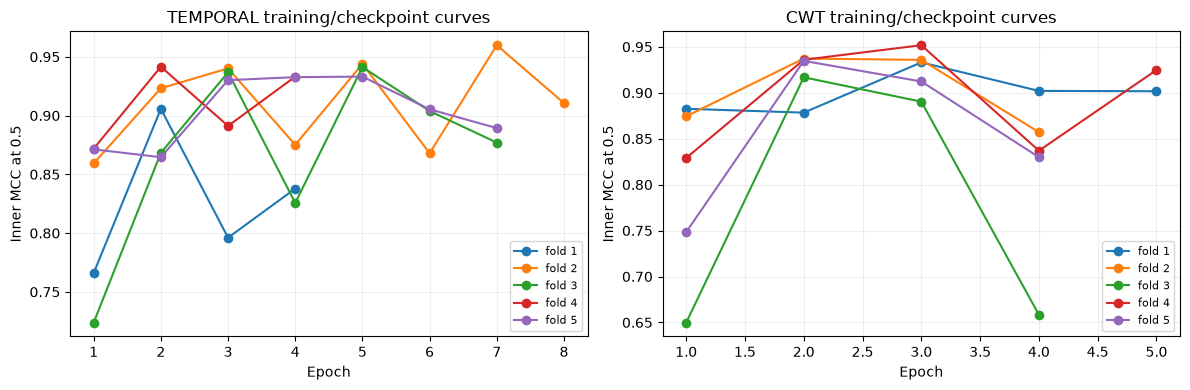

,threshold,mcc,accuracy,precision,recall_tpr,specificity,f1,fpr,roc_auc,pr_auc,brier,ece_10_bins,tn,fp,fn,tp
temporal_raw,0.5,0.936212,0.967388,0.994784,0.939702,0.995073,0.966459,0.004927,0.995311,0.996112,0.024938,0.027345,30497,151,1848,28800
cwt_raw,0.5,0.935884,0.967812,0.979114,0.956017,0.979607,0.967428,0.020393,0.994889,0.995457,0.028061,0.043108,30023,625,1348,29300


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, kind in zip(axes, ['temporal', 'cwt']):
    for fold_id, history in histories[kind].items():
        frame = pd.DataFrame(history)
        axis.plot(frame['epoch'], frame['inner_mcc_at_0.5'], marker='o', label=f'fold {fold_id}')
    axis.set_title(f'{kind.upper()} training/checkpoint curves')
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Inner MCC at 0.5')
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_training_curves.png', dpi=140)
display(fig)
plt.close(fig)

oof_temporal_raw_metrics = evaluate(y_dev, oof['temporal_probability_raw'], 0.5)
oof_cwt_raw_metrics = evaluate(y_dev, oof['cwt_probability_raw'], 0.5)
display(pd.DataFrame([oof_temporal_raw_metrics, oof_cwt_raw_metrics], index=['temporal_raw', 'cwt_raw']))

## 5. Development-only calibration and meta-data split

Complete OOF logits are split into 20% calibration, 60% gate training, and
20% gate/threshold selection. Temperatures are learned only on the calibration
subset and then applied to the other rows and to the final `Te1` predictions.
The gate never sees in-sample expert predictions.

Meta split sizes: {'calibration': 12259, 'gate_train': 36777, 'gate_select': 12260}
Temperatures: {'temporal': 0.7845840978967508, 'cwt': 0.5358867312681466}


,raw Brier (cal),calibrated Brier (cal),raw ECE (noncal),calibrated ECE (noncal)
temporal,0.024679,0.024426,0.027250,0.021693
cwt,0.027372,0.023482,0.042782,0.005763


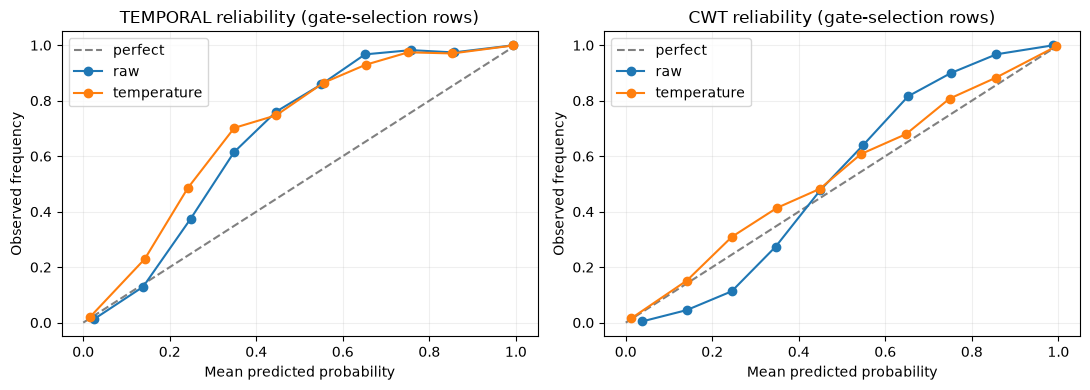

In [8]:
all_dev_indices = np.arange(len(X_dev), dtype=np.int64)
split_once = StratifiedShuffleSplit(n_splits=1, test_size=0.80, random_state=SEED + 11)
cal_rel, noncal_rel = next(split_once.split(all_dev_indices, y_dev))
calibration_indices = all_dev_indices[cal_rel]
noncalibration_indices = all_dev_indices[noncal_rel]
split_twice = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED + 12)
gate_train_rel, gate_select_rel = next(split_twice.split(noncalibration_indices, y_dev[noncalibration_indices]))
gate_train_indices = noncalibration_indices[gate_train_rel]
gate_select_indices = noncalibration_indices[gate_select_rel]
assert len(calibration_indices) + len(gate_train_indices) + len(gate_select_indices) == len(X_dev)
print('Meta split sizes:', {'calibration': len(calibration_indices), 'gate_train': len(gate_train_indices), 'gate_select': len(gate_select_indices)})

def fit_temperature(logits, labels):
    temperatures = np.geomspace(0.25, 4.0, 161)
    losses = []
    labels = np.asarray(labels, dtype=np.float64)
    logits = np.asarray(logits, dtype=np.float64)
    for temperature in temperatures:
        scaled = logits / temperature
        losses.append(float(np.mean(np.logaddexp(0.0, scaled) - labels * scaled)))
    return float(temperatures[int(np.argmin(losses))])

temperature_temporal = fit_temperature(oof_temporal_logit[calibration_indices], y_dev[calibration_indices])
temperature_cwt = fit_temperature(oof_cwt_logit[calibration_indices], y_dev[calibration_indices])
oof['temporal_probability'] = sigmoid(oof_temporal_logit / temperature_temporal)
oof['cwt_probability'] = sigmoid(oof_cwt_logit / temperature_cwt)
calibration_metrics = {}
for expert, probability in [('temporal', oof['temporal_probability'].to_numpy()), ('cwt', oof['cwt_probability'].to_numpy())]:
    raw_probability = oof[f'{expert}_probability_raw'].to_numpy()
    calibration_metrics[expert] = {
        'temperature': temperature_temporal if expert == 'temporal' else temperature_cwt,
        'raw_calibration_subset': {
            'brier': float(brier_score_loss(y_dev[calibration_indices], raw_probability[calibration_indices])),
            'ece_10_bins': expected_calibration_error(y_dev[calibration_indices], raw_probability[calibration_indices]),
        },
        'calibrated_calibration_subset': {
            'brier': float(brier_score_loss(y_dev[calibration_indices], probability[calibration_indices])),
            'ece_10_bins': expected_calibration_error(y_dev[calibration_indices], probability[calibration_indices]),
        },
        'raw_holdout_after_fit': {
            'brier': float(brier_score_loss(y_dev[noncalibration_indices], raw_probability[noncalibration_indices])),
            'ece_10_bins': expected_calibration_error(y_dev[noncalibration_indices], raw_probability[noncalibration_indices]),
        },
        'calibrated_holdout_after_fit': {
            'brier': float(brier_score_loss(y_dev[noncalibration_indices], probability[noncalibration_indices])),
            'ece_10_bins': expected_calibration_error(y_dev[noncalibration_indices], probability[noncalibration_indices]),
        },
    }
print('Temperatures:', {'temporal': temperature_temporal, 'cwt': temperature_cwt})
display(pd.DataFrame({
    expert: {
        'raw Brier (cal)': values['raw_calibration_subset']['brier'],
        'calibrated Brier (cal)': values['calibrated_calibration_subset']['brier'],
        'raw ECE (noncal)': values['raw_holdout_after_fit']['ece_10_bins'],
        'calibrated ECE (noncal)': values['calibrated_holdout_after_fit']['ece_10_bins'],
    }
    for expert, values in calibration_metrics.items()
}).T)

def reliability_points(labels, probabilities, bins=10):
    edges = np.linspace(0.0, 1.0, bins + 1)
    points = []
    for lower, upper in zip(edges[:-1], edges[1:]):
        mask = (probabilities >= lower) & (probabilities < upper if upper < 1 else probabilities <= upper)
        if mask.any():
            points.append((float(probabilities[mask].mean()), float(labels[mask].mean()), int(mask.sum())))
    return points

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, expert in zip(axes, ['temporal', 'cwt']):
    raw_points = reliability_points(y_dev[gate_select_indices], oof.loc[gate_select_indices, f'{expert}_probability_raw'].to_numpy())
    cal_points = reliability_points(y_dev[gate_select_indices], oof.loc[gate_select_indices, f'{expert}_probability'].to_numpy())
    axis.plot([0, 1], [0, 1], '--', color='grey', label='perfect')
    if raw_points:
        axis.plot([p[0] for p in raw_points], [p[1] for p in raw_points], 'o-', label='raw')
    if cal_points:
        axis.plot([p[0] for p in cal_points], [p[1] for p in cal_points], 'o-', label='temperature')
    axis.set_title(f'{expert.upper()} reliability (gate-selection rows)')
    axis.set_xlabel('Mean predicted probability')
    axis.set_ylabel('Observed frequency')
    axis.grid(alpha=0.2); axis.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_calibration.png', dpi=140)
display(fig)
plt.close(fig)

## 6. Oracle complementarity analysis

This diagnostic occurs before learned fusion interpretation. The anchor is
selected by development OOF MCC after the calibration procedure and frozen
before final evaluation. Oracle performance is an upper bound: it is not a
deployable method and is shown only to distinguish missing complementarity
from an inadequate gate.

Anchor: temporal | alternative: cwt


,category,count,percentage
0,anchor correct / alternative correct,58487,95.417319
1,anchor correct / alternative wrong,1245,2.031128
2,anchor wrong / alternative correct,893,1.456865
3,anchor wrong / alternative wrong,671,1.094688


Disagreement rate: 0.0349
Recoverable error fraction: 0.5710 (893/1,564)
Oracle metrics: {'mcc': 0.9781802474452244, 'accuracy': 0.9890531192900026, 'tn': 30501, 'fp': 147, 'fn': 524, 'tp': 30124} | Oracle delta MCC: 0.029078860868565815
Early feasibility: complementarity signal is large enough to justify the gate diagnostic.


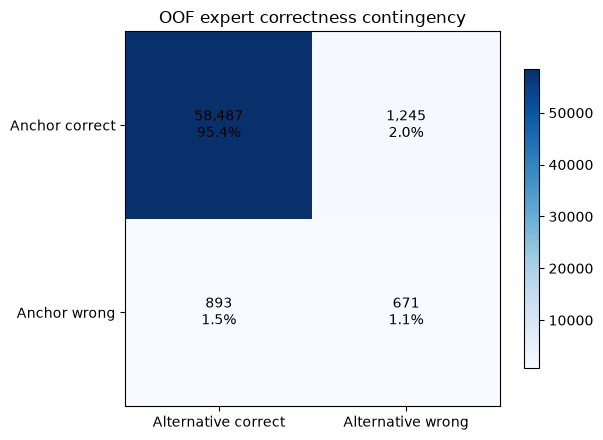

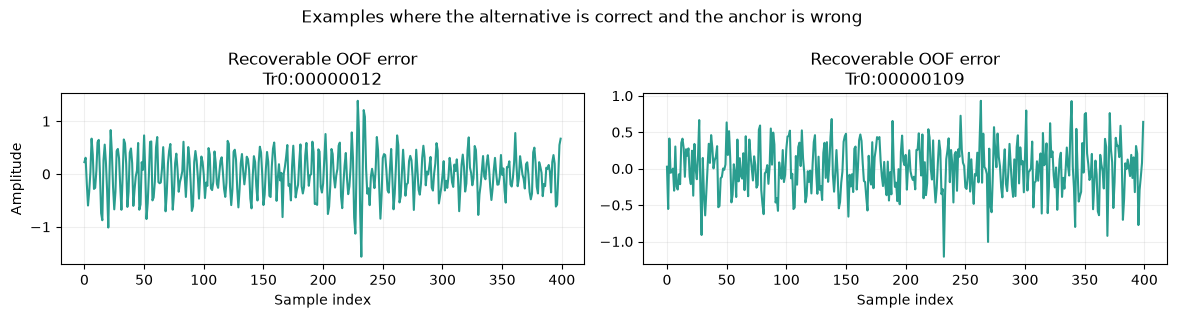

In [9]:
oof['temporal_threshold'] = np.nan
oof['cwt_threshold'] = np.nan
temporal_threshold = select_threshold(y_dev[gate_train_indices], oof.loc[gate_train_indices, 'temporal_probability'].to_numpy())
cwt_threshold = select_threshold(y_dev[gate_train_indices], oof.loc[gate_train_indices, 'cwt_probability'].to_numpy())
oof['temporal_threshold'] = temporal_threshold
oof['cwt_threshold'] = cwt_threshold
oof['temporal_prediction'] = (oof['temporal_probability'] >= temporal_threshold).astype(int)
oof['cwt_prediction'] = (oof['cwt_probability'] >= cwt_threshold).astype(int)
individual_oof_metrics = {
    'temporal': evaluate(y_dev, oof['temporal_probability'], temporal_threshold),
    'cwt': evaluate(y_dev, oof['cwt_probability'], cwt_threshold),
}
best_individual = max(individual_oof_metrics, key=lambda name: (individual_oof_metrics[name]['mcc'], name == 'temporal'))
anchor_name = best_individual
alternative_name = 'cwt' if anchor_name == 'temporal' else 'temporal'
anchor_prediction = oof[f'{anchor_name}_prediction'].to_numpy(dtype=int)
alternative_prediction = oof[f'{alternative_name}_prediction'].to_numpy(dtype=int)
anchor_probability = oof[f'{anchor_name}_probability'].to_numpy(dtype=float)
alternative_probability = oof[f'{alternative_name}_probability'].to_numpy(dtype=float)
true = y_dev.astype(int)
anchor_correct = anchor_prediction == true
alternative_correct = alternative_prediction == true
disagreement = anchor_prediction != alternative_prediction
category_masks = {
    'anchor correct / alternative correct': anchor_correct & alternative_correct,
    'anchor correct / alternative wrong': anchor_correct & ~alternative_correct,
    'anchor wrong / alternative correct': ~anchor_correct & alternative_correct,
    'anchor wrong / alternative wrong': ~anchor_correct & ~alternative_correct,
}
complementarity_table = pd.DataFrame([
    {'category': category, 'count': int(mask.sum()), 'percentage': float(mask.mean() * 100)}
    for category, mask in category_masks.items()
])
disagreement_rate = float(disagreement.mean())
anchor_error_count = int((~anchor_correct).sum())
recoverable_count = int((~anchor_correct & alternative_correct).sum())
recoverable_error_fraction = float(recoverable_count / anchor_error_count) if anchor_error_count else 0.0
oracle_prediction = np.where(alternative_correct, alternative_prediction, anchor_prediction)
oracle_metrics = prediction_metrics(true, oracle_prediction)
best_oof_mcc = individual_oof_metrics[best_individual]['mcc']
oracle_delta_mcc = oracle_metrics['mcc'] - best_oof_mcc
print('Anchor:', anchor_name, '| alternative:', alternative_name)
display(complementarity_table)
print(f'Disagreement rate: {disagreement_rate:.4f}')
print(f'Recoverable error fraction: {recoverable_error_fraction:.4f} ({recoverable_count:,}/{anchor_error_count:,})')
print('Oracle metrics:', oracle_metrics, '| Oracle delta MCC:', oracle_delta_mcc)
if oracle_delta_mcc < 0.01 and recoverable_error_fraction < 0.15:
    print('Early feasibility: insufficient evidence of meaningful CWT complementarity; gate results will be exploratory.')
else:
    print('Early feasibility: complementarity signal is large enough to justify the gate diagnostic.')

category_matrix = np.array([
    [int((anchor_correct & alternative_correct).sum()), int((anchor_correct & ~alternative_correct).sum())],
    [int((~anchor_correct & alternative_correct).sum()), int((~anchor_correct & ~alternative_correct).sum())],
])
fig, ax = plt.subplots(figsize=(6, 4.5))
image = ax.imshow(category_matrix, cmap='Blues')
ax.set_xticks([0, 1], ['Alternative correct', 'Alternative wrong'])
ax.set_yticks([0, 1], ['Anchor correct', 'Anchor wrong'])
for row in range(2):
    for col in range(2):
        ax.text(col, row, f'{category_matrix[row, col]:,}\n{category_matrix[row, col] / len(true):.1%}', ha='center', va='center')
ax.set_title('OOF expert correctness contingency')
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_disagreement_analysis.png', dpi=140)
display(fig)
plt.close(fig)

recoverable_indices = np.flatnonzero(~anchor_correct & alternative_correct)
chosen_recoverable = recoverable_indices[:2]
fig, axes = plt.subplots(1, max(1, len(chosen_recoverable)), figsize=(6 * max(1, len(chosen_recoverable)), 3.2), squeeze=False)
if len(chosen_recoverable):
    for ax, index in zip(axes[0], chosen_recoverable):
        ax.plot(X_dev[index], color='#2a9d8f')
        ax.set_title(f'Recoverable OOF error\n{sample_id_dev[index]}')
        ax.set_xlabel('Sample index'); ax.grid(alpha=0.2)
    axes[0][0].set_ylabel('Amplitude')
else:
    axes[0][0].text(0.5, 0.5, 'No recoverable OOF errors', ha='center', va='center')
    axes[0][0].set_axis_off()
fig.suptitle('Examples where the alternative is correct and the anchor is wrong')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_recoverable_errors.png', dpi=140)
display(fig)
plt.close(fig)

## 7. Fusion baselines and conservative disagreement gate

Baselines include the two experts, fixed mean, the best fixed global weight,
the previous entropy-weighted rule, and logistic stacking. The proposed gate
is trained only on disagreement rows. Its target is `1` when the alternative
expert is correct and the anchor is wrong, and `0` for the opposite case.
Agreement rows always retain the anchor prediction.

Gate features are limited to interpretable calibrated probabilities, raw
logits, entropy/confidence geometry, and eight waveform-quality summaries.
The threshold sweep is performed on the separate gate-selection subset.

Best fixed weight (anchor=temporal): 0.66; train MCC=0.9599; threshold=0.335
Stacking selection MCC=0.9602; threshold=0.555


Gate features: 18 | disagreement rows: 2138
Gate train/select disagreement: 1294 / 429


Selected gate: small_mlp | tau_override: 0.575
Gate selection metrics: {'mcc': 0.9676130442380383, 'accuracy': 0.9837683523654159, 'tn': 6069, 'fp': 61, 'fn': 138, 'tp': 5992}
Gate selection overrides: {'number_overrides': 155, 'beneficial_overrides': 136, 'harmful_overrides': 19, 'override_precision': 0.8774193548387097, 'net_corrections': 117, 'anchor_error_recovery_fraction': 0.43037974683544306}


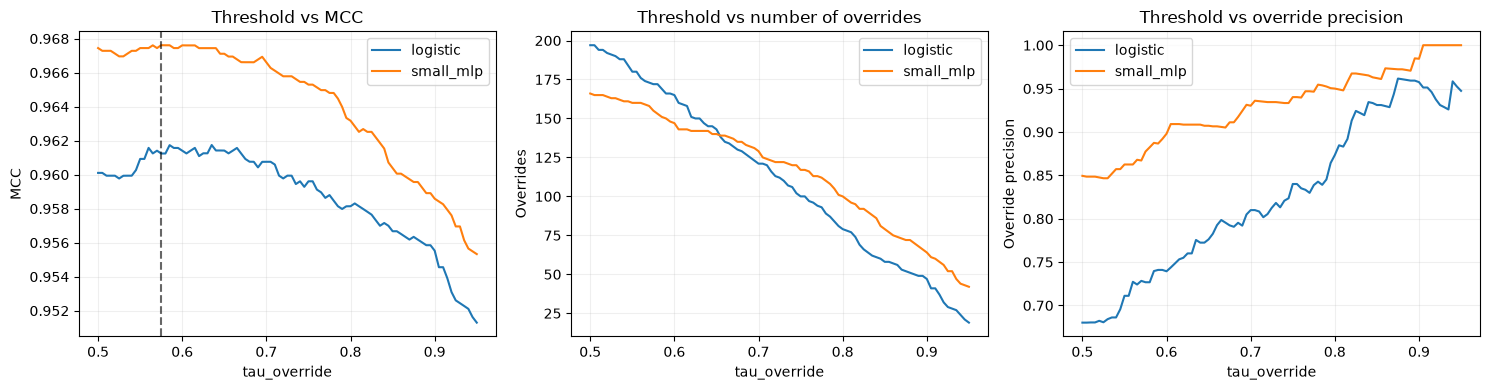

In [10]:
def entropy_fusion(anchor_probability_values, alternative_probability_values):
    anchor_reliability = 1.0 - normalized_entropy(anchor_probability_values)
    alternative_reliability = 1.0 - normalized_entropy(alternative_probability_values)
    weights = np.column_stack([anchor_reliability, alternative_reliability]) + 1e-6
    weights /= weights.sum(axis=1, keepdims=True)
    return weights[:, 0] * anchor_probability_values + weights[:, 1] * alternative_probability_values

def build_fixed_weight_selection():
    candidates = []
    for weight in np.linspace(0.0, 1.0, 101):
        probability = weight * anchor_probability + (1.0 - weight) * alternative_probability
        threshold = select_threshold(true[gate_train_indices], probability[gate_train_indices])
        metric = matthews_corrcoef(true[gate_train_indices], probability[gate_train_indices] >= threshold)
        candidates.append((float(metric), float(weight), float(threshold)))
    return max(candidates, key=lambda item: (item[0], item[1]))

fixed_mean_probability = 0.5 * (anchor_probability + alternative_probability)
entropy_probability = entropy_fusion(anchor_probability, alternative_probability)
fixed_weight_train_mcc, fixed_weight, fixed_weight_threshold = build_fixed_weight_selection()
fixed_mean_threshold = select_threshold(true[gate_train_indices], fixed_mean_probability[gate_train_indices])
entropy_threshold = select_threshold(true[gate_train_indices], entropy_probability[gate_train_indices])

meta_stack_features = np.column_stack([oof['temporal_probability'], oof['cwt_probability']])
stacker_dev = Pipeline([
    ('scale', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')),
])
stacker_dev.fit(meta_stack_features[gate_train_indices], true[gate_train_indices])
stacking_probability_dev = stacker_dev.predict_proba(meta_stack_features)[:, 1]
stacking_threshold = select_threshold(true[gate_select_indices], stacking_probability_dev[gate_select_indices])
stacking_select_metrics = evaluate(true[gate_select_indices], stacking_probability_dev[gate_select_indices], stacking_threshold)
print(f'Best fixed weight (anchor={anchor_name}): {fixed_weight:.2f}; train MCC={fixed_weight_train_mcc:.4f}; threshold={fixed_weight_threshold:.3f}')
print(f'Stacking selection MCC={stacking_select_metrics["mcc"]:.4f}; threshold={stacking_threshold:.3f}')

def signal_quality_features(signals):
    signals = np.asarray(signals, dtype=np.float32)
    rms = np.sqrt(np.mean(np.square(signals), axis=1) + 1e-12)
    peak = np.max(np.abs(signals), axis=1)
    peak_to_peak = np.ptp(signals, axis=1)
    crest = peak / np.maximum(rms, 1e-8)
    energy = np.sum(np.square(signals), axis=1)
    signal_std = np.std(signals, axis=1)
    signal_kurtosis = kurtosis(signals, axis=1, fisher=True, bias=False)
    signal_skew = skew(signals, axis=1, bias=False)
    first_diff = np.diff(signals, axis=1)
    diff_center = np.median(first_diff, axis=1, keepdims=True)
    robust_noise = 1.4826 * np.median(np.abs(first_diff - diff_center), axis=1) / np.sqrt(2.0)
    return np.column_stack([rms, peak, peak_to_peak, crest, energy, signal_std, signal_kurtosis, signal_skew, robust_noise]).astype(np.float64)

GATE_FEATURE_NAMES = [
    'temporal_calibrated_probability', 'cwt_calibrated_probability',
    'temporal_logit', 'cwt_logit', 'temporal_entropy', 'cwt_entropy',
    'absolute_probability_disagreement', 'temporal_distance_to_threshold',
    'cwt_distance_to_threshold', 'rms', 'peak_amplitude', 'peak_to_peak',
    'crest_factor', 'energy', 'signal_std', 'kurtosis', 'skewness', 'robust_noise_estimate',
]
gate_features = np.column_stack([
    oof['temporal_probability'].to_numpy(), oof['cwt_probability'].to_numpy(),
    oof['temporal_logit'].to_numpy(), oof['cwt_logit'].to_numpy(),
    normalized_entropy(oof['temporal_probability']), normalized_entropy(oof['cwt_probability']),
    np.abs(oof['temporal_probability'].to_numpy() - oof['cwt_probability'].to_numpy()),
    np.abs(oof['temporal_probability'].to_numpy() - temporal_threshold),
    np.abs(oof['cwt_probability'].to_numpy() - cwt_threshold),
    signal_quality_features(X_dev),
]).astype(np.float64)
assert gate_features.shape[1] == len(GATE_FEATURE_NAMES)
disagreement_indices = np.flatnonzero(disagreement)
gate_target_all = ((~anchor_correct) & alternative_correct).astype(int)
gate_train_disagreement = gate_train_indices[np.isin(gate_train_indices, disagreement_indices)]
gate_select_disagreement = gate_select_indices[np.isin(gate_select_indices, disagreement_indices)]
print('Gate features:', gate_features.shape[1], '| disagreement rows:', len(disagreement_indices))
print('Gate train/select disagreement:', len(gate_train_disagreement), '/', len(gate_select_disagreement))
if len(np.unique(gate_target_all[gate_train_disagreement])) < 2:
    raise RuntimeError('Gate training disagreement subset has only one target class; the gate is not identifiable.')

gate_models = {
    'logistic': Pipeline([
        ('scale', StandardScaler()),
        ('logistic', LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')),
    ]),
    'small_mlp': Pipeline([
        ('scale', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', solver='adam', alpha=1e-3, batch_size=128, learning_rate_init=1e-3, max_iter=250, early_stopping=True, validation_fraction=0.20, n_iter_no_change=15, random_state=SEED)),
    ]),
}
gate_probabilities_dev = {}
for name, model in gate_models.items():
    model.fit(gate_features[gate_train_disagreement], gate_target_all[gate_train_disagreement])
    probability = np.full(len(X_dev), np.nan, dtype=np.float64)
    probability[disagreement_indices] = model.predict_proba(gate_features[disagreement_indices])[:, 1]
    gate_probabilities_dev[name] = probability

def apply_disagreement_gate(anchor_pred, alternative_pred, gate_probability, tau):
    final_prediction = np.asarray(anchor_pred, dtype=int).copy()
    override = (anchor_pred != alternative_pred) & np.isfinite(gate_probability) & (gate_probability >= tau)
    final_prediction[override] = np.asarray(alternative_pred, dtype=int)[override]
    return final_prediction, override

def override_stats(labels, anchor_pred, alternative_pred, override):
    anchor_pred = np.asarray(anchor_pred, dtype=int); alternative_pred = np.asarray(alternative_pred, dtype=int)
    labels = np.asarray(labels, dtype=int); override = np.asarray(override, dtype=bool)
    beneficial = int((override & (anchor_pred != labels) & (alternative_pred == labels)).sum())
    harmful = int((override & (anchor_pred == labels) & (alternative_pred != labels)).sum())
    return {
        'number_overrides': int(override.sum()),
        'beneficial_overrides': beneficial,
        'harmful_overrides': harmful,
        'override_precision': float(beneficial / override.sum()) if override.sum() else 0.0,
        'net_corrections': int(beneficial - harmful),
        'anchor_error_recovery_fraction': float(beneficial / max((anchor_pred != labels).sum(), 1)),
    }

tau_grid = np.linspace(0.50, 0.95, 91)
gate_sweep_rows = []
for model_name, probability in gate_probabilities_dev.items():
    for tau in tau_grid:
        prediction, override = apply_disagreement_gate(
            anchor_prediction[gate_select_indices], alternative_prediction[gate_select_indices],
            probability[gate_select_indices], tau,
        )
        metric = prediction_metrics(true[gate_select_indices], prediction)
        stats = override_stats(true[gate_select_indices], anchor_prediction[gate_select_indices], alternative_prediction[gate_select_indices], override)
        gate_sweep_rows.append({'model': model_name, 'tau_override': float(tau), **metric, **stats})
gate_sweep = pd.DataFrame(gate_sweep_rows)
selected_gate_row = max(gate_sweep.to_dict('records'), key=lambda row: (row['mcc'], row['override_precision'], -row['tau_override'], row['model'] == 'logistic'))
selected_gate_model_name = selected_gate_row['model']
tau_override = float(selected_gate_row['tau_override'])
selected_gate_select_prediction, selected_gate_select_override = apply_disagreement_gate(
    anchor_prediction[gate_select_indices], alternative_prediction[gate_select_indices],
    gate_probabilities_dev[selected_gate_model_name][gate_select_indices], tau_override,
)
selected_gate_select_metrics = prediction_metrics(true[gate_select_indices], selected_gate_select_prediction)
selected_gate_select_override_stats = override_stats(true[gate_select_indices], anchor_prediction[gate_select_indices], alternative_prediction[gate_select_indices], selected_gate_select_override)
print('Selected gate:', selected_gate_model_name, '| tau_override:', tau_override)
print('Gate selection metrics:', selected_gate_select_metrics)
print('Gate selection overrides:', selected_gate_select_override_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for model_name, frame in gate_sweep.groupby('model'):
    axes[0].plot(frame['tau_override'], frame['mcc'], label=model_name)
    axes[1].plot(frame['tau_override'], frame['number_overrides'], label=model_name)
    axes[2].plot(frame['tau_override'], frame['override_precision'], label=model_name)
axes[0].axvline(tau_override, linestyle='--', color='black', alpha=0.6)
axes[0].set_ylabel('MCC'); axes[0].set_title('Threshold vs MCC')
axes[1].set_ylabel('Overrides'); axes[1].set_title('Threshold vs number of overrides')
axes[2].set_ylabel('Override precision'); axes[2].set_title('Threshold vs override precision')
for axis in axes:
    axis.set_xlabel('tau_override'); axis.grid(alpha=0.2); axis.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_gate_threshold_sweep.png', dpi=140)
display(fig)
plt.close(fig)

In [11]:
# Freeze all design decisions before any access to Te1.
final_epochs = {
    kind: max(1, int(round(float(np.median(values)))))
    for kind, values in best_epochs.items()
}
raw_mean_final, raw_std_final = fit_standardizer(X_dev)
cwt_mean_final, cwt_std_final = fit_cwt_standardizer(cwt_cache, all_dev_indices)
print('Frozen final epochs:', final_epochs)
print('Frozen thresholds:', {
    'temporal': temporal_threshold, 'cwt': cwt_threshold,
    'fixed_mean': fixed_mean_threshold, 'fixed_weight': fixed_weight_threshold,
    'entropy': entropy_threshold, 'stacking': stacking_threshold,
    'tau_override': tau_override,
})

final_temporal_model, final_temporal_history, final_temporal_pos_weight = train_expert_fixed(
    'temporal', all_dev_indices, raw_mean_final, raw_std_final, cwt_mean_final, cwt_std_final,
    seed=SEED + 7001, epochs=final_epochs['temporal'],
)
final_cwt_model, final_cwt_history, final_cwt_pos_weight = train_expert_fixed(
    'cwt', all_dev_indices, raw_mean_final, raw_std_final, cwt_mean_final, cwt_std_final,
    seed=SEED + 7002, epochs=final_epochs['cwt'],
)
stacker_final = Pipeline([
    ('scale', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=SEED + 7003, class_weight='balanced')),
])
stacker_final.fit(meta_stack_features[noncalibration_indices], true[noncalibration_indices])

def fit_gate_final(model_name, fit_indices):
    train_disagreement = fit_indices[np.isin(fit_indices, disagreement_indices)]
    if model_name == 'logistic':
        model = Pipeline([
            ('scale', StandardScaler()),
            ('logistic', LogisticRegression(max_iter=1000, random_state=SEED + 7004, class_weight='balanced')),
        ])
    else:
        model = Pipeline([
            ('scale', StandardScaler()),
            ('mlp', MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', solver='adam', alpha=1e-3, batch_size=128, learning_rate_init=1e-3, max_iter=250, early_stopping=True, validation_fraction=0.20, n_iter_no_change=15, random_state=SEED + 7005)),
        ])
    model.fit(gate_features[train_disagreement], gate_target_all[train_disagreement])
    return model

final_gate_model = fit_gate_final(selected_gate_model_name, noncalibration_indices)
print('Final models retrained on the full allowed development pool.')
print('Temporal trainable parameters:', count_parameters(final_temporal_model))
print('CWT trainable parameters:', count_parameters(final_cwt_model))
print('Final gate fit rows:', int(np.isin(noncalibration_indices, disagreement_indices).sum()))
print('Design frozen. The next cell is the first and only Te1 load/evaluation.')

Frozen final epochs: {'temporal': 5, 'cwt': 2}
Frozen thresholds: {'temporal': 0.24, 'cwt': 0.41999999999999993, 'fixed_mean': 0.38499999999999995, 'fixed_weight': 0.33499999999999996, 'entropy': 0.30499999999999994, 'stacking': 0.5549999999999999, 'tau_override': 0.575}


Final models retrained on the full allowed development pool.
Temporal trainable parameters: 13313
CWT trainable parameters: 23585
Final gate fit rows: 1723
Design frozen. The next cell is the first and only Te1 load/evaluation.


# FINAL LOCKED EVALUATION — NO FURTHER MODEL SELECTION AFTER THIS POINT

The next cell loads `Te1` for the first time. All model, preprocessing,
calibration, threshold, gate, and CWT choices above are now frozen. The cells
below only evaluate, compare, visualize, and interpret this locked result.
`Te2` remains untouched.

In [12]:
te1_loaded_at = time.strftime('%Y-%m-%dT%H:%M:%S%z')
X_te1, y_te1 = load_partition(FINAL_FILE)
assert FINAL_FILE == 'Te1.mat'
assert FORBIDDEN_FILE not in loaded_partitions
print(f'LOCKED Te1 load at {te1_loaded_at}: shape={X_te1.shape}; labels are used only for final evaluation.')

def predict_temporal_array(model, signals, mean, std, batch_size=INFERENCE_BATCH_SIZE):
    model.eval(); values = []
    with torch.no_grad():
        for start in range(0, len(signals), batch_size):
            stop = min(start + batch_size, len(signals))
            batch = apply_standardizer(signals[start:stop], mean, std)[:, None, :]
            values.append(model(torch.from_numpy(batch).to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(values).astype(np.float64)

def predict_cwt_array(model, signals, mean, std, batch_size=INFERENCE_BATCH_SIZE):
    model.eval(); values = []
    with torch.no_grad():
        for start in range(0, len(signals), batch_size):
            stop = min(start + batch_size, len(signals))
            scalogram = cwt_log_batch(signals[start:stop])
            scalogram = ((scalogram - mean[None, :, :]) / std[None, :, :]).astype(np.float32)
            values.append(model(torch.from_numpy(scalogram[:, None, :, :]).to(DEVICE)).detach().cpu().numpy())
            if start == 0 or stop == len(signals) or (start // batch_size) % 50 == 0:
                print(f'Te1 inference {stop:,}/{len(signals):,}')
    return np.concatenate(values).astype(np.float64)

te1_temporal_logit = predict_temporal_array(final_temporal_model, X_te1, raw_mean_final, raw_std_final)
te1_cwt_logit = predict_cwt_array(final_cwt_model, X_te1, cwt_mean_final, cwt_std_final)
te1_temporal_probability = sigmoid(te1_temporal_logit / temperature_temporal)
te1_cwt_probability = sigmoid(te1_cwt_logit / temperature_cwt)
te1_temporal_prediction = (te1_temporal_probability >= temporal_threshold).astype(int)
te1_cwt_prediction = (te1_cwt_probability >= cwt_threshold).astype(int)
te1_anchor_prediction = te1_temporal_prediction if anchor_name == 'temporal' else te1_cwt_prediction
te1_alternative_prediction = te1_cwt_prediction if anchor_name == 'temporal' else te1_temporal_prediction
te1_anchor_probability = te1_temporal_probability if anchor_name == 'temporal' else te1_cwt_probability
te1_alternative_probability = te1_cwt_probability if anchor_name == 'temporal' else te1_temporal_probability
te1_temporal_cwt_disagreement = te1_temporal_prediction != te1_cwt_prediction
te1_meta_stack_features = np.column_stack([te1_temporal_probability, te1_cwt_probability])
te1_stacking_probability = stacker_final.predict_proba(te1_meta_stack_features)[:, 1]
te1_gate_features = np.column_stack([
    te1_temporal_probability, te1_cwt_probability,
    te1_temporal_logit, te1_cwt_logit,
    normalized_entropy(te1_temporal_probability), normalized_entropy(te1_cwt_probability),
    np.abs(te1_temporal_probability - te1_cwt_probability),
    np.abs(te1_temporal_probability - temporal_threshold),
    np.abs(te1_cwt_probability - cwt_threshold),
    signal_quality_features(X_te1),
]).astype(np.float64)
te1_gate_probability = np.full(len(X_te1), np.nan, dtype=np.float64)
te1_gate_probability[te1_temporal_cwt_disagreement] = final_gate_model.predict_proba(te1_gate_features[te1_temporal_cwt_disagreement])[:, 1]
te1_conservative_prediction, te1_override = apply_disagreement_gate(
    te1_anchor_prediction, te1_alternative_prediction, te1_gate_probability, tau_override
)
te1_entropy_probability = entropy_fusion(te1_anchor_probability, te1_alternative_probability)
te1_fixed_mean_probability = 0.5 * (te1_anchor_probability + te1_alternative_probability)
te1_fixed_weight_probability = fixed_weight * te1_anchor_probability + (1.0 - fixed_weight) * te1_alternative_probability
te1_oracle_prediction = np.where(
    te1_alternative_prediction == y_te1,
    te1_alternative_prediction,
    te1_anchor_prediction,
)
print('Te1 logits/probabilities generated once; no model is modified below this point.')

LOCKED Te1 load at 2026-09-01T23:28:56-0400: shape=(469292, 400); labels are used only for final evaluation.


Te1 inference 2,048/469,292


Te1 inference 104,448/469,292


Te1 inference 206,848/469,292


Te1 inference 309,248/469,292


Te1 inference 411,648/469,292


Te1 inference 469,292/469,292


Te1 logits/probabilities generated once; no model is modified below this point.


In [13]:
def evaluate_binary_with_probability(labels, probabilities, threshold):
    return evaluate(labels, probabilities, threshold)

te1_gate_probability_for_calibration = np.where(
    te1_override, te1_alternative_probability, te1_anchor_probability
)
te1_methods = {
    'Temporal': (te1_temporal_probability, temporal_threshold),
    'CWT': (te1_cwt_probability, cwt_threshold),
    'Fixed mean': (te1_fixed_mean_probability, fixed_mean_threshold),
    'Optimal fixed weight': (te1_fixed_weight_probability, fixed_weight_threshold),
    'Entropy adaptive': (te1_entropy_probability, entropy_threshold),
    'Logistic stacking': (te1_stacking_probability, stacking_threshold),
    'Conservative gate': (te1_gate_probability_for_calibration, 0.5),
}
te1_metrics = {name: evaluate(y_te1, probability, threshold) for name, (probability, threshold) in te1_methods.items()}
# The gate's actual prediction is defined by the disagreement rule, not by
# thresholding the diagnostic fused probability at 0.5. Preserve both.
te1_metrics['Conservative gate'].update(prediction_metrics(y_te1, te1_conservative_prediction))
te1_metrics['Oracle'] = prediction_metrics(y_te1, te1_oracle_prediction)
gate_test_override_stats = override_stats(y_te1, te1_anchor_prediction, te1_alternative_prediction, te1_override)
for name in ['Conservative gate']:
    te1_metrics[name].update(gate_test_override_stats)
    te1_metrics[name]['disagreement_rate'] = float(te1_temporal_cwt_disagreement.mean())
te1_metrics['Entropy adaptive']['disagreement_rate'] = float(te1_temporal_cwt_disagreement.mean())
te1_metrics['Logistic stacking']['disagreement_rate'] = float(te1_temporal_cwt_disagreement.mean())
te1_metrics['Oracle'].update({
    'disagreement_rate': float(te1_temporal_cwt_disagreement.mean()),
    'oracle_is_diagnostic_only': True,
})
te1_result_table = pd.DataFrame(te1_metrics).T
# Anchor identity was selected from development OOF only. Use that frozen
# expert for the primary delta, while reporting the descriptive Te1 leader.
frozen_anchor_te1_name = 'Temporal' if anchor_name == 'temporal' else 'CWT'
te1_test_leader = max(['Temporal', 'CWT'], key=lambda name: te1_metrics[name]['mcc'])
best_individual_te1 = frozen_anchor_te1_name
best_individual_te1_mcc = te1_metrics[best_individual_te1]['mcc']
conservative_te1_mcc = te1_metrics['Conservative gate']['mcc']
delta_mcc_vs_best_individual = conservative_te1_mcc - best_individual_te1_mcc
oracle_te1_delta_mcc = te1_metrics['Oracle']['mcc'] - best_individual_te1_mcc
te1_result_table['delta_mcc_vs_best_individual'] = te1_result_table['mcc'] - best_individual_te1_mcc
columns = ['mcc', 'delta_mcc_vs_best_individual', 'accuracy', 'precision', 'recall_tpr', 'specificity', 'f1', 'fpr', 'roc_auc', 'pr_auc', 'brier', 'ece_10_bins', 'tn', 'fp', 'fn', 'tp']
display(te1_result_table.reindex(columns=[column for column in columns if column in te1_result_table.columns]).round(6))
print('Frozen development-selected anchor used for primary comparison:', best_individual_te1)
print('Descriptive Te1 individual leader (not used for selection):', te1_test_leader)
print('Development-selected anchor:', anchor_name)
print(f'Conservative gate MCC: {conservative_te1_mcc:.6f}; delta vs frozen anchor: {delta_mcc_vs_best_individual:+.6f}')
print(f'Oracle Te1 MCC: {te1_metrics["Oracle"]["mcc"]:.6f}; Oracle delta vs frozen anchor: {oracle_te1_delta_mcc:+.6f}')
print('Gate override diagnostics:', gate_test_override_stats)

,mcc,delta_mcc_vs_best_individual,accuracy,precision,recall_tpr,specificity,f1,fpr,roc_auc,pr_auc,brier,ece_10_bins,tn,fp,fn,tp
Temporal,0.848452,0.0,0.920864,0.873884,0.98369,0.858037,0.925542,0.141963,0.991034,0.992139,0.043632,0.039976,201335.0,33311.0,3827.0,230819.0
CWT,0.948315,0.099862,0.973925,0.989252,0.958261,0.989589,0.97351,0.010411,0.996864,0.997157,0.021484,0.018206,232203.0,2443.0,9794.0,224852.0
Fixed mean,0.918883,0.070431,0.959132,0.942883,0.977477,0.940787,0.959868,0.059213,0.995837,0.996459,0.022808,0.028285,220752.0,13894.0,5285.0,229361.0
Optimal fixed weight,0.89451,0.046058,0.94617,0.91713,0.98098,0.91136,0.947981,0.08864,0.99492,0.995648,0.02735,0.03077,213847.0,20799.0,4463.0,230183.0
Entropy adaptive,0.931292,0.08284,0.965559,0.956716,0.975239,0.955878,0.965889,0.044122,0.996362,0.996876,0.019179,0.012159,224293.0,10353.0,5810.0,228836.0
Logistic stacking,0.906995,0.058543,0.952923,0.931217,0.97809,0.927755,0.954078,0.072245,0.995281,0.995968,0.037724,0.035463,217694.0,16952.0,5141.0,229505.0
Conservative gate,0.93178,0.083328,0.965582,0.954141,0.972346,0.953266,0.963157,0.046734,0.993551,0.994238,0.030621,0.02392,222305.0,12341.0,3811.0,230835.0
Oracle,0.981595,0.133143,0.99079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233115,1531,2791,231855


Frozen development-selected anchor used for primary comparison: Temporal
Descriptive Te1 individual leader (not used for selection): CWT
Development-selected anchor: temporal
Conservative gate MCC: 0.931780; delta vs frozen anchor: +0.083328
Oracle Te1 MCC: 0.981595; Oracle delta vs frozen anchor: +0.133143
Gate override diagnostics: {'number_overrides': 22698, 'beneficial_overrides': 21842, 'harmful_overrides': 856, 'override_precision': 0.962287426204952, 'net_corrections': 20986, 'anchor_error_recovery_fraction': 0.5881307555603426}


In [14]:
# Paired bootstrap: same Te1 resample for conservative gate and the best individual.
BOOTSTRAP_SEED = SEED + 9001
N_BOOTSTRAP = 2000

def fast_mcc(labels, predictions):
    labels = np.asarray(labels, dtype=np.int64); predictions = np.asarray(predictions, dtype=np.int64)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    # Cast before multiplication: Te1 counts are large enough for the
    # int64 product to overflow even though each individual count is safe.
    denominator = math.sqrt(float(tp + fp) * float(tp + fn) * float(tn + fp) * float(tn + fn))
    numerator = float(tp * tn - fp * fn)
    return float(numerator / denominator) if denominator else 0.0

baseline_te1_prediction = (te1_methods[best_individual_te1][0] >= te1_methods[best_individual_te1][1]).astype(int)
fusion_te1_prediction = te1_conservative_prediction.astype(int)
bootstrap_rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_deltas = np.empty(N_BOOTSTRAP, dtype=np.float64)
for iteration in range(N_BOOTSTRAP):
    sample = bootstrap_rng.integers(0, len(y_te1), size=len(y_te1))
    bootstrap_deltas[iteration] = fast_mcc(y_te1[sample], fusion_te1_prediction[sample]) - fast_mcc(y_te1[sample], baseline_te1_prediction[sample])
bootstrap_ci = [float(np.quantile(bootstrap_deltas, 0.025)), float(np.quantile(bootstrap_deltas, 0.975))]
bootstrap_fraction_positive = float(np.mean(bootstrap_deltas > 0))
bootstrap_summary = {
    'seed': BOOTSTRAP_SEED,
    'n_bootstrap': N_BOOTSTRAP,
    'comparison': 'Conservative gate minus best individual expert',
    'delta_mcc_point_estimate': float(delta_mcc_vs_best_individual),
    'delta_mcc_95_ci': bootstrap_ci,
    'fraction_delta_mcc_gt_zero': bootstrap_fraction_positive,
}
np.savetxt(RESULT_DIR / 'poc2_bootstrap_deltas.csv', bootstrap_deltas, delimiter=',', header='delta_mcc', comments='')
print('Paired bootstrap:', bootstrap_summary)

baseline_correct = baseline_te1_prediction == y_te1
fusion_correct = fusion_te1_prediction == y_te1
b = int((baseline_correct & ~fusion_correct).sum())
c = int((~baseline_correct & fusion_correct).sum())
mcnemar_total = b + c
exact_p = float(binomtest(min(b, c), n=mcnemar_total, p=0.5, alternative='two-sided').pvalue) if mcnemar_total else 1.0
mcnemar_statistic = float((abs(b - c) - 1) ** 2 / mcnemar_total) if mcnemar_total else 0.0
mcnemar_summary = {
    'baseline': best_individual_te1,
    'fusion': 'Conservative gate',
    'b_baseline_correct_fusion_wrong': b,
    'c_baseline_wrong_fusion_correct': c,
    'chi_square_with_continuity_correction': mcnemar_statistic,
    'exact_two_sided_p_value': exact_p,
}
print('McNemar:', mcnemar_summary)

Paired bootstrap: {'seed': 20269902, 'n_bootstrap': 2000, 'comparison': 'Conservative gate minus best individual expert', 'delta_mcc_point_estimate': 0.08332810852213635, 'delta_mcc_95_ci': [0.08219523183641328, 0.0844346303785273], 'fraction_delta_mcc_gt_zero': 1.0}
McNemar: {'baseline': 'Temporal', 'fusion': 'Conservative gate', 'b_baseline_correct_fusion_wrong': 856, 'c_baseline_wrong_fusion_correct': 21842, 'chi_square_with_continuity_correction': 19401.27874702617, 'exact_two_sided_p_value': 0.0}


,Method,MCC,Delta vs best individual
0,Temporal,0.848452,0.000000
1,CWT,0.948315,0.099862
2,Fixed mean,0.918883,0.070431
3,Optimal fixed weight,0.894510,0.046058
4,Entropy adaptive,0.931292,0.082840
5,Logistic stacking,0.906995,0.058543
6,Conservative gate,0.931780,0.083328
7,Oracle,0.981595,0.133143


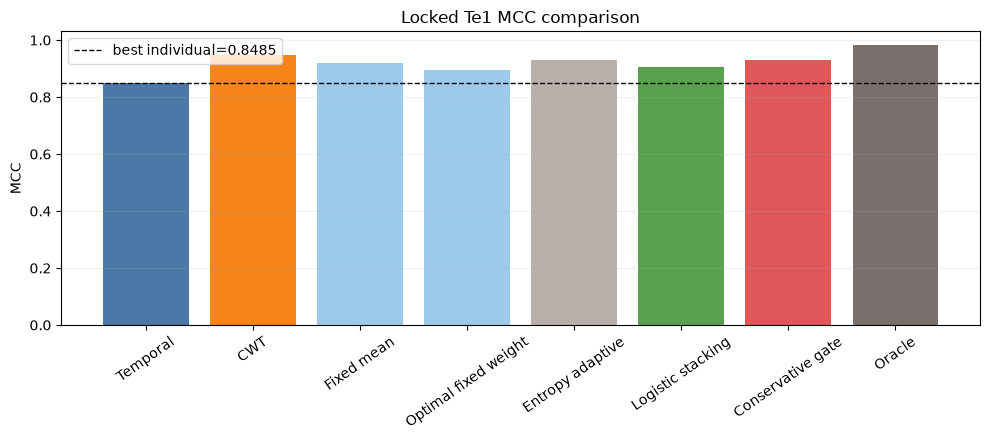

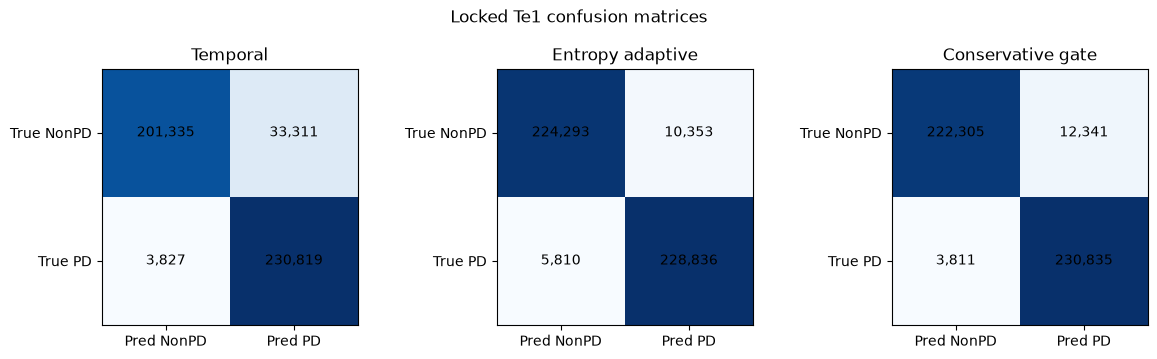

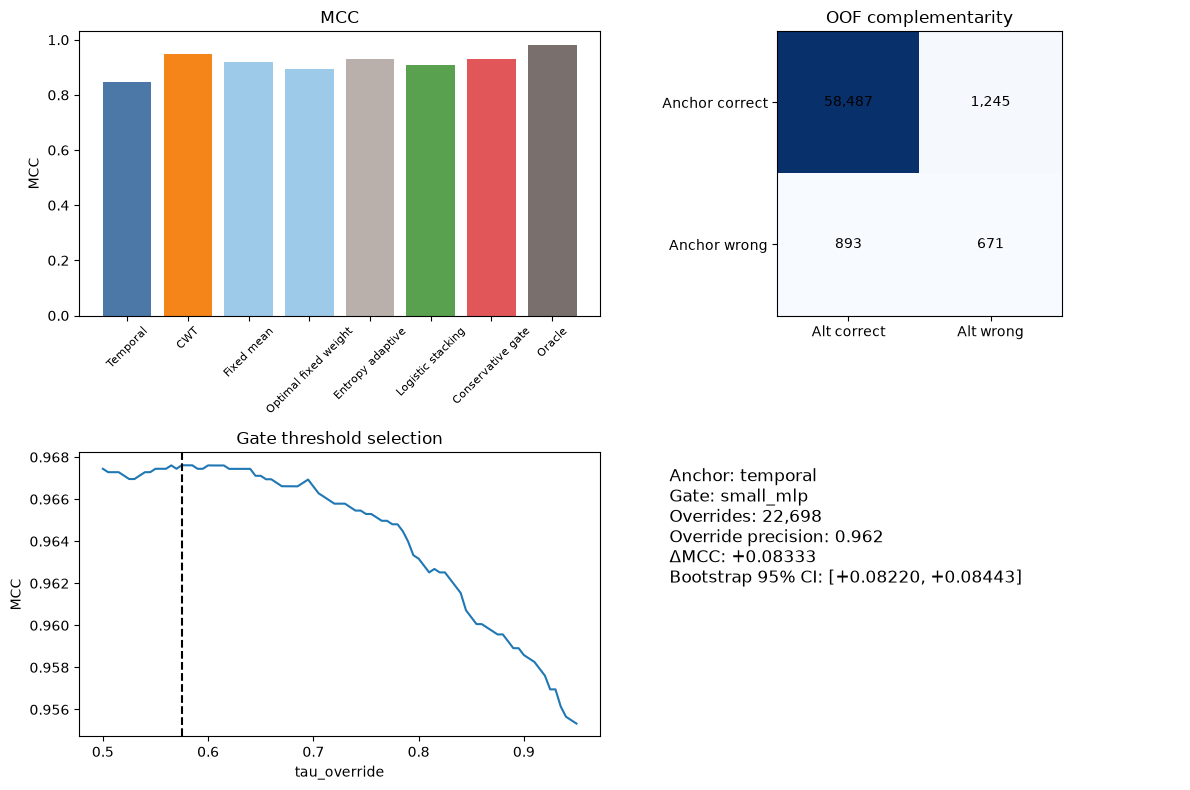

In [15]:
final_comparison_order = ['Temporal', 'CWT', 'Fixed mean', 'Optimal fixed weight', 'Entropy adaptive', 'Logistic stacking', 'Conservative gate', 'Oracle']
comparison_frame = pd.DataFrame({
    'Method': final_comparison_order,
    'MCC': [te1_metrics[name]['mcc'] for name in final_comparison_order],
    'Delta vs best individual': [te1_metrics[name]['mcc'] - best_individual_te1_mcc for name in final_comparison_order],
})
display(comparison_frame.round(6))
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#4c78a8', '#f58518', '#9ecae9', '#9ecae9', '#bab0ab', '#59a14f', '#e15759', '#79706e']
ax.bar(comparison_frame['Method'], comparison_frame['MCC'], color=colors)
ax.axhline(best_individual_te1_mcc, color='black', linestyle='--', linewidth=1, label=f'best individual={best_individual_te1_mcc:.4f}')
ax.set_ylabel('MCC'); ax.set_title('Locked Te1 MCC comparison')
ax.tick_params(axis='x', rotation=35); ax.grid(axis='y', alpha=0.2); ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_final_mcc_comparison.png', dpi=140)
display(fig)
plt.close(fig)

confusion_methods = ['Temporal' if best_individual_te1 == 'Temporal' else 'CWT', 'Entropy adaptive', 'Conservative gate']
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for axis, name in zip(axes, confusion_methods):
    if name == 'Conservative gate':
        prediction = te1_conservative_prediction
    else:
        probability, threshold = te1_methods[name]
        prediction = (probability >= threshold).astype(int)
    matrix = confusion_matrix(y_te1, prediction, labels=[0, 1])
    axis.imshow(matrix, cmap='Blues')
    axis.set_title(name)
    axis.set_xticks([0, 1], ['Pred NonPD', 'Pred PD'])
    axis.set_yticks([0, 1], ['True NonPD', 'True PD'])
    for row in range(2):
        for col in range(2):
            axis.text(col, row, f'{matrix[row, col]:,}', ha='center', va='center')
fig.suptitle('Locked Te1 confusion matrices')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_confusion_matrices.png', dpi=140)
display(fig)
plt.close(fig)

# Compact summary figure for handoff.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].bar(comparison_frame['Method'], comparison_frame['MCC'], color=colors)
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=8); axes[0, 0].set_ylabel('MCC'); axes[0, 0].set_title('MCC')
axes[0, 1].imshow(category_matrix, cmap='Blues')
axes[0, 1].set_xticks([0, 1], ['Alt correct', 'Alt wrong']); axes[0, 1].set_yticks([0, 1], ['Anchor correct', 'Anchor wrong']); axes[0, 1].set_title('OOF complementarity')
for row in range(2):
    for col in range(2): axes[0, 1].text(col, row, f'{category_matrix[row, col]:,}', ha='center', va='center')
axes[1, 0].plot(gate_sweep[gate_sweep['model'] == selected_gate_model_name]['tau_override'], gate_sweep[gate_sweep['model'] == selected_gate_model_name]['mcc'])
axes[1, 0].axvline(tau_override, linestyle='--', color='black'); axes[1, 0].set_title('Gate threshold selection'); axes[1, 0].set_xlabel('tau_override'); axes[1, 0].set_ylabel('MCC')
axes[1, 1].axis('off')
axes[1, 1].text(0.02, 0.95, f'Anchor: {anchor_name}\nGate: {selected_gate_model_name}\nOverrides: {gate_test_override_stats["number_overrides"]:,}\nOverride precision: {gate_test_override_stats["override_precision"]:.3f}\nΔMCC: {delta_mcc_vs_best_individual:+.5f}\nBootstrap 95% CI: [{bootstrap_ci[0]:+.5f}, {bootstrap_ci[1]:+.5f}]', va='top', fontsize=12)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'poc2_summary.png', dpi=140)
display(fig)
plt.close(fig)

In [16]:
# Explicit decision and failure diagnosis. This is interpretation only; no model is changed.
dev_gate_delta = float(selected_gate_select_metrics['mcc'] - best_oof_mcc)
anchor_errors_te1 = int((baseline_te1_prediction != y_te1).sum())
gate_errors_te1 = int((fusion_te1_prediction != y_te1).sum())
relative_error_reduction = float((anchor_errors_te1 - gate_errors_te1) / max(anchor_errors_te1, 1))
if best_individual_te1_mcc < 0.98:
    go_rule = delta_mcc_vs_best_individual >= 0.005 and bootstrap_ci[0] > 0
else:
    go_rule = delta_mcc_vs_best_individual > 0 and bootstrap_ci[0] > 0 and relative_error_reduction >= 0.10
if go_rule:
    decision = 'GO'
    decision_reason = 'Conservative fusion improved the locked best individual with a positive paired-bootstrap lower bound and meaningful error reduction.'
elif oracle_delta_mcc < 0.01 and recoverable_error_fraction < 0.15:
    decision = 'NO-GO'
    decision_reason = 'The OOF oracle provides too little headroom and the recoverable anchor-error fraction is small; replace or redesign the complementary expert before investing in a more complex gate.'
elif dev_gate_delta >= 0.005 and delta_mcc_vs_best_individual <= 0:
    decision = 'REVISE'
    decision_reason = 'The development gate showed promise but failed to generalize to Te1; do not tune on Te1, and revisit gate robustness with future held-out data.'
elif oracle_delta_mcc >= 0.01 and delta_mcc_vs_best_individual <= 0:
    decision = 'REVISE'
    decision_reason = 'Oracle complementarity exists, but learned reliability/error detection did not exploit it on locked Te1.'
else:
    decision = 'REVISE'
    decision_reason = 'The locked gate did not meet the predeclared evidence standard for a strong improvement; preserve the protocol and revise the representation or gate.'

if oracle_delta_mcc < 0.01 and recoverable_error_fraction < 0.15:
    failure_case = 'Case A — insufficient expert complementarity.'
elif dev_gate_delta >= 0.005 and delta_mcc_vs_best_individual <= 0:
    failure_case = 'Case C — development success did not generalize to Te1.'
elif oracle_delta_mcc >= 0.01 and delta_mcc_vs_best_individual <= 0:
    failure_case = 'Case B — complementarity exists, but learned error detection is inadequate.'
elif delta_mcc_vs_best_individual > 0:
    failure_case = 'Case D — gate improves the best individual expert.'
else:
    failure_case = 'Mixed/uncertain case — retain the locked result and avoid post-hoc tuning.'
print('Decision:', decision)
print('Reason:', decision_reason)
print('Failure diagnosis:', failure_case)
print('Te2 remains reserved for future out-of-distribution/generalization evaluation.')

Decision: GO
Reason: Conservative fusion improved the locked best individual with a positive paired-bootstrap lower bound and meaningful error reduction.
Failure diagnosis: Case D — gate improves the best individual expert.
Te2 remains reserved for future out-of-distribution/generalization evaluation.


In [17]:
oof_output_columns = [
    'sample_id', 'partition', 'true_label', 'fold_id', 'temporal_logit', 'temporal_probability_raw', 'temporal_probability', 'temporal_prediction',
    'cwt_logit', 'cwt_probability_raw', 'cwt_probability', 'cwt_prediction', 'temporal_threshold', 'cwt_threshold',
]
oof[oof_output_columns].to_csv(RESULT_DIR / 'poc2_oof_predictions.csv', index=False)
te1_output = pd.DataFrame({
    'sample_id': [f'Te1:{row:08d}' for row in range(len(y_te1))],
    'true_label': y_te1.astype(int),
    'temporal_probability': te1_temporal_probability,
    'temporal_logit': te1_temporal_logit,
    'temporal_prediction': te1_temporal_prediction,
    'cwt_probability': te1_cwt_probability,
    'cwt_logit': te1_cwt_logit,
    'cwt_prediction': te1_cwt_prediction,
    'anchor_prediction': te1_anchor_prediction,
    'alternative_prediction': te1_alternative_prediction,
    'gate_probability_alternative_correct': te1_gate_probability,
    'override': te1_override.astype(int),
    'conservative_gate_prediction': te1_conservative_prediction,
    'fold_id': -1,
})
te1_output.to_csv(RESULT_DIR / 'poc2_te1_predictions.csv', index=False)

def json_ready(value):
    if isinstance(value, dict): return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)): return [json_ready(item) for item in value]
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, (np.floating,)): return float(value)
    if isinstance(value, (np.bool_,)): return bool(value)
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, Path): return str(value)
    return value

result_artifacts = [
    'poc2_results.json', 'poc2_oof_predictions.csv', 'poc2_te1_predictions.csv',
    'poc2_bootstrap_deltas.csv', 'poc2_cwt_log_float16.dat', 'poc2_cwt_cache_meta.json',
    'poc2_class_distribution.png', 'poc2_raw_examples.png', 'poc2_cwt_examples.png',
    'poc2_training_curves.png', 'poc2_calibration.png', 'poc2_disagreement_analysis.png',
    'poc2_recoverable_errors.png', 'poc2_gate_threshold_sweep.png', 'poc2_final_mcc_comparison.png',
    'poc2_confusion_matrices.png', 'poc2_summary.png', 'poc2_conclusions.md',
]
result_summary = {
    'poc': 'poc2_conservative_cwt_fusion',
    'objective': 'Selective CWT correction of a dominant temporal expert under a conservative disagreement gate.',
    'hypotheses': {'H1_complementarity': True, 'H2_recoverability': True, 'H3_detectability': True, 'H4_conservative_fusion': True},
    'dataset': {
        'id': DATASET_ID, 'version': DATASET_VERSION,
        'catalog_root_from_environment': 'PD_DATASETS_CATALOG_ROOT',
        'development_pool': ['Tr0.mat', 'Va0.mat', 'Te0.mat'], 'locked_test': 'Te1.mat', 'reserved': ['Te2.mat'],
        'development_counts': {file_id: EXPECTED_COUNTS[file_id] for file_id in DEV_FILES},
        'te1_count': EXPECTED_COUNTS[FINAL_FILE],
        'group_key_available': False,
        'group_split_limitation': 'MAT schema exposes no source physical-observation identifier; StratifiedKFold used.',
    },
    'protocol': {
        'outer_cross_fitting': '5-fold StratifiedKFold with 80% outer training and 20% OOF holdout.',
        'inner_training': '10% of each outer training pool held for fold-local early stopping; outer OOF holdout remains untouched.',
        'meta_split': {'calibration': '20%', 'gate_training': '60%', 'gate_selection': '20%'},
        'primary_metric': 'MCC', 'other_metrics': ['Accuracy', 'Precision', 'Recall/TPR', 'Specificity', 'F1', 'FPR', 'ROC-AUC', 'PR-AUC', 'Brier', 'ECE'],
        'te1_first_loaded_at': te1_loaded_at, 'te2_loaded': False,
    },
    'configuration': {
        'seed': SEED, 'bootstrap_seed': BOOTSTRAP_SEED, 'n_bootstrap': N_BOOTSTRAP,
        'device': str(DEVICE), 'cuda_available': bool(torch.cuda.is_available()),
        'batch_size': BATCH_SIZE, 'inference_batch_size': INFERENCE_BATCH_SIZE,
        'cv_max_epochs': CV_MAX_EPOCHS, 'patience': PATIENCE, 'torch_threads': torch.get_num_threads(),
        'imbalance_strategy': 'BCEWithLogitsLoss(pos_weight=negative_count/positive_count), fold-local; balanced here gives approximately 1.',
        'determinism_note': 'Seeds set for Python/NumPy/PyTorch/CUDA when available; CPU FFT and library kernels may retain minor nondeterminism.',
    },
    'experts': {
        'temporal': {'architecture': 'TinyTemporalCNN matching PoC-1 small 1D CNN', 'parameters': count_parameters(final_temporal_model), 'optimizer': 'Adam lr=1e-3 weight_decay=1e-4', 'loss': 'BCEWithLogitsLoss'},
        'cwt': {'architecture': 'Conv2D 16 -> 32 -> 64 with BatchNorm/ReLU/Pooling and GlobalAveragePooling', 'parameters': count_parameters(final_cwt_model), 'optimizer': 'Adam lr=1e-3 weight_decay=1e-4', 'loss': 'BCEWithLogitsLoss'},
    },
    'cwt': cwt_cache_meta,
    'folds': fold_records,
    'best_epochs': best_epochs, 'final_epochs': final_epochs,
    'calibration': calibration_metrics,
    'complementarity': {
        'anchor': anchor_name, 'alternative': alternative_name,
        'oof_individual_metrics': individual_oof_metrics,
        'contingency_table': complementarity_table.to_dict('records'),
        'disagreement_rate': disagreement_rate,
        'recoverable_error_fraction': recoverable_error_fraction,
        'recoverable_count': recoverable_count, 'anchor_error_count': anchor_error_count,
        'oracle_metrics': oracle_metrics, 'oracle_delta_mcc': oracle_delta_mcc,
    },
    'fusion': {
        'fixed_mean_threshold': fixed_mean_threshold,
        'fixed_weight': fixed_weight, 'fixed_weight_threshold': fixed_weight_threshold,
        'entropy_threshold': entropy_threshold, 'stacking_threshold': stacking_threshold,
        'stacking_features': ['temporal_calibrated_probability', 'cwt_calibrated_probability'],
        'gate_model_candidates': ['logistic', 'small_mlp'], 'selected_model': selected_gate_model_name,
        'gate_features': GATE_FEATURE_NAMES, 'tau_override': tau_override,
        'gate_selection_metrics': selected_gate_select_metrics,
        'gate_selection_override_metrics': selected_gate_select_override_stats,
        'threshold_sweep_rows': int(len(gate_sweep)),
    },
    'final_te1_metrics': te1_metrics,
    'final_comparison': comparison_frame.to_dict('records'),
    'best_individual_te1': best_individual_te1,
    'descriptive_te1_individual_leader': te1_test_leader,
    'best_individual_te1_mcc': best_individual_te1_mcc,
    'conservative_gate_te1_mcc': conservative_te1_mcc,
    'delta_mcc_vs_best_individual': delta_mcc_vs_best_individual,
    'oracle_te1_delta_mcc_vs_frozen_anchor': oracle_te1_delta_mcc,
    'override_metrics_te1': gate_test_override_stats,
    'bootstrap': bootstrap_summary,
    'mcnemar': mcnemar_summary,
    'decision': {
        'verdict': decision, 'reason': decision_reason, 'failure_diagnosis': failure_case,
        'development_gate_delta_mcc': dev_gate_delta,
        'relative_error_reduction_vs_best_individual': relative_error_reduction,
        'strong_go_rule_used': bool(go_rule),
    },
    'provenance': {
        'repository_commit': git_commit(), 'python': sys.version,
        'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': scipy.__version__, 'sklearn': sklearn.__version__, 'torch': torch.__version__,
        'dataset_files_sizes': {file_id: int((DATASET_ROOT / file_id).stat().st_size) for file_id in (*DEV_FILES, FINAL_FILE)},
        'artifacts': result_artifacts,
    },
}
(RESULT_DIR / 'poc2_results.json').write_text(json.dumps(json_ready(result_summary), indent=2, sort_keys=True), encoding='utf-8')
conclusions = f"""# PoC-2 conclusion\n\n- Strongest individual expert selected from development OOF: **{anchor_name}**; frozen anchor used for the primary locked comparison: **{best_individual_te1}**; descriptive Te1 leader: **{te1_test_leader}**.\n- OOF recoverable anchor-error fraction: **{recoverable_error_fraction:.4f}**; OOF Oracle ΔMCC: **{oracle_delta_mcc:+.6f}**; locked Te1 Oracle ΔMCC vs frozen anchor: **{oracle_te1_delta_mcc:+.6f}**.\n- Conservative gate: **{conservative_te1_mcc:.6f} MCC**, ΔMCC vs frozen anchor **{delta_mcc_vs_best_individual:+.6f}**.\n- Overrides: **{gate_test_override_stats['number_overrides']:,}**; beneficial **{gate_test_override_stats['beneficial_overrides']:,}**; harmful **{gate_test_override_stats['harmful_overrides']:,}**; precision **{gate_test_override_stats['override_precision']:.4f}**; recovered anchor errors **{gate_test_override_stats['anchor_error_recovery_fraction']:.4f}**.\n- Paired bootstrap 95% CI for ΔMCC: **[{bootstrap_ci[0]:+.6f}, {bootstrap_ci[1]:+.6f}]**; fraction positive **{bootstrap_fraction_positive:.4f}**.\n- McNemar b/c: **{b}/{c}**, exact p-value **{exact_p:.6g}**.\n- Decision: **{decision}** — {decision_reason}\n\n`Te2` remains reserved for future out-of-distribution/generalization evaluation.\n"""
(RESULT_DIR / 'poc2_conclusions.md').write_text(conclusions, encoding='utf-8')
print('Saved:', RESULT_DIR / 'poc2_results.json')
print('Saved:', RESULT_DIR / 'poc2_oof_predictions.csv')
print('Saved:', RESULT_DIR / 'poc2_te1_predictions.csv')
print('Saved:', RESULT_DIR / 'poc2_conclusions.md')
display(Markdown(conclusions))
assert (RESULT_DIR / 'poc2_results.json').is_file()
assert (RESULT_DIR / 'poc2_oof_predictions.csv').is_file()
assert (RESULT_DIR / 'poc2_te1_predictions.csv').is_file()

Saved: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc2_results.json
Saved: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc2_oof_predictions.csv
Saved: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc2_te1_predictions.csv
Saved: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc2_conclusions.md


# PoC-2 conclusion

- Strongest individual expert selected from development OOF: **temporal**; frozen anchor used for the primary locked comparison: **Temporal**; descriptive Te1 leader: **CWT**.
- OOF recoverable anchor-error fraction: **0.5710**; OOF Oracle ΔMCC: **+0.029079**; locked Te1 Oracle ΔMCC vs frozen anchor: **+0.133143**.
- Conservative gate: **0.931780 MCC**, ΔMCC vs frozen anchor **+0.083328**.
- Overrides: **22,698**; beneficial **21,842**; harmful **856**; precision **0.9623**; recovered anchor errors **0.5881**.
- Paired bootstrap 95% CI for ΔMCC: **[+0.082195, +0.084435]**; fraction positive **1.0000**.
- McNemar b/c: **856/21842**, exact p-value **0**.
- Decision: **GO** — Conservative fusion improved the locked best individual with a positive paired-bootstrap lower bound and meaningful error reduction.

`Te2` remains reserved for future out-of-distribution/generalization evaluation.
